In [10]:
import pandas as pd 
import matplotlib.pyplot as plt 

In [11]:
orders = pd.read_csv('orders.csv')
orders.head(5)

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49


In [12]:
order_items = pd.read_csv('order_items.csv')
order_items.head(5)

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49


In [13]:
order_item_refunds = pd.read_csv('order_item_refunds.csv')
order_item_refunds.head(5)

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd
0,1,2012-04-06 11:32:43,57,57,49.99
1,2,2012-04-13 01:09:43,74,74,49.99
2,3,2012-04-15 07:03:48,71,71,49.99
3,4,2012-04-17 20:00:37,118,118,49.99
4,5,2012-04-22 20:53:49,116,116,49.99


In [14]:
website_sessions = pd.read_csv('website_sessions.csv')
website_sessions.head(5)

,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
0,1,19-03-2012 08:04,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
1,2,19-03-2012 08:16,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
2,3,19-03-2012 08:26,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
3,4,19-03-2012 08:37,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
4,5,19-03-2012 09:00,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com


In [15]:
website_pageviews = pd.read_csv('website_pageviews.csv')
website_pageviews.head(5)

,website_pageview_id,created_at,website_session_id,pageview_url
0,1,2012-03-19 08:04:16,1,/home
1,2,2012-03-19 08:16:49,2,/home
2,3,2012-03-19 08:26:55,3,/home
3,4,2012-03-19 08:37:33,4,/home
4,5,2012-03-19 09:00:55,5,/home


In [16]:
products = pd.read_csv('products.csv')
products.head(5)

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


In [17]:
### Business Overview 
Total_orders = orders['order_id'].count()
Total_Cost = orders['cogs_usd'].sum()
Total_Revenue = orders['price_usd'].sum()
Total_Refunded_Amt = order_item_refunds['refund_amount_usd'].sum()
Refunded_items_Cost = pd.merge(order_items,order_item_refunds,how = 'right',on = 'order_item_id')['cogs_usd'].sum()
Total_Net_Revenue = Total_Revenue - Total_Refunded_Amt
Total_Net_Cost = Total_Cost - Refunded_items_Cost
Profit = Total_Net_Revenue - Total_Net_Cost
Profit_Margin = (Profit/Total_Net_Revenue)*100

print(f'Total_orders : ',Total_orders)
print(f'Total_Cost :',Total_Cost)
print(f'Gross_Revenue :',Total_Revenue)
print(f'Total_Refunded_Amt :',Total_Refunded_Amt)
print(f'Refunded_items_Cost :',Refunded_items_Cost)
print(f'Total_Net_Revenue :', Total_Net_Revenue)
print(f'Total_Net_Cost :',Total_Net_Cost)
print(f'Profit :',Profit)
print(f'Profit_Margin:',Profit_Margin)

Total_orders :  32313
Total_Cost : 722370.25
Gross_Revenue : 1938509.7500000002
Total_Refunded_Amt : 85338.69
Refunded_items_Cost : 31979.190000000002
Total_Net_Revenue : 1853171.0600000003
Total_Net_Cost : 690391.06
Profit : 1162780.0000000002
Profit_Margin: 62.74542189321692


In [18]:
orders['user_id'].nunique()

31696

In [19]:
#### Business Trends 

orders['created_at'] = pd.to_datetime(orders['created_at'])
orders['year'] = orders.created_at.dt.year
orders['month'] = orders['created_at'].dt.month

In [20]:
starting_3_year_data = orders[orders['year'].isin([2012,2013,2014])]
starting_3_year_data

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd,year,month
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49,2012,3
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49,2012,3
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49,2012,3
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49,2012,3
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49,2012,3
...,...,...,...,...,...,...,...,...,...,...
26888,26889,2014-12-31 19:23:55,408523,344194,1,1,49.99,19.49,2014,12
26889,26890,2014-12-31 20:50:11,408582,309480,1,1,49.99,19.49,2014,12
26890,26891,2014-12-31 21:44:46,408611,344260,1,1,49.99,19.49,2014,12
26891,26892,2014-12-31 22:17:34,408626,344273,1,2,95.98,33.98,2014,12


In [21]:
### Gross Revenue change year on year 

year_Gross_revenue = starting_3_year_data.groupby('year')['price_usd'].sum().sort_index().reset_index()
previous_year_revenue = year_Gross_revenue['price_usd'].shift(1)
YOY_change = ((year_Gross_revenue['price_usd']-previous_year_revenue)/previous_year_revenue)*100
YOY_change = YOY_change.fillna(0)
Year_wise_Revenue_change = pd.DataFrame({'Years':year_Gross_revenue['year'],'YOY_change':YOY_change})
Year_wise_Revenue_change['Years'] = Year_wise_Revenue_change['Years'].astype('int')


month_Gross_revenue = starting_3_year_data.groupby('month')['price_usd'].sum().sort_index().reset_index()
previous_month_revenue = month_Gross_revenue['price_usd'].shift(1)
MOM_change = ((month_Gross_revenue['price_usd']-previous_month_revenue)/previous_month_revenue)*100
MOM_change = MOM_change.fillna(0)
Month_wise_revenue_change = pd.DataFrame({'Months':month_Gross_revenue['month'],'MOM_change':MOM_change})
print(Year_wise_Revenue_change)
print('----------------------')
print(Month_wise_revenue_change)


   Years  YOY_change
0   2012    0.000000
1   2013  204.196856
2   2014  173.520157
----------------------
    Months  MOM_change
0        1    0.000000
1        2   20.895737
2        3   -1.558736
3        4   23.245941
4        5   10.190345
5        6   -4.935032
6        7    4.495896
7        8    3.749080
8        9    9.267991
9       10   15.356151
10      11   27.998980
11      12   11.032612


In [22]:
### How is the Revenue is changing yearly & monthly 

# # YOY Change & MoM Change

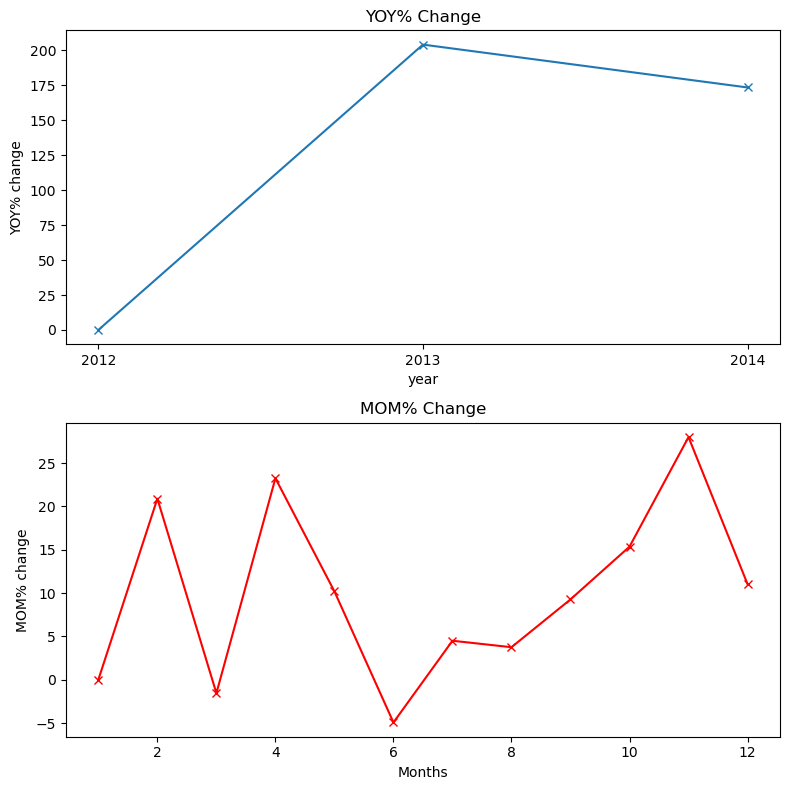

In [23]:
fig,axes = plt.subplots(2,1,figsize = (8,8))

axes[0].plot(Year_wise_Revenue_change['Years'] , Year_wise_Revenue_change['YOY_change'],marker= 'x')
axes[0].set_xticks(Year_wise_Revenue_change['Years'])
axes[0].set_xlabel('year')
axes[0].set_ylabel('YOY% change')
axes[0].set_title('YOY% Change')

axes[1].plot(Month_wise_revenue_change['Months'],Month_wise_revenue_change['MOM_change'],marker = 'x',color = 'r' )
axes[1].set_xlabel('Months')
axes[1].set_ylabel('MOM% change')
axes[1].set_title('MOM% Change')
plt.tight_layout()
plt.show()

In [24]:
### from 2012 - 2013 there is a explosive growth 
### form 2013 - 2014 --- there is still growth but it is not like a
### explosive growth which we have seen in last two years 

In [25]:
Month_wise_revenue_change = Month_wise_revenue_change.to_csv('Month_wise_revenue_change.csv',index = False)
Month_wise_revenue_change

In [26]:
Year_wise_Revenue_change = Year_wise_Revenue_change.to_csv('Year_wise_Revenue_change.csv',index = False)
Year_wise_Revenue_change

In [27]:
orders['year_month'] = orders['created_at'].dt.to_period('M')

In [28]:
revenue_year_months_trends = orders.groupby(['year_month']).agg(Sales = ('price_usd','sum'),Orders_count = ('order_id','nunique'))
revenue_year_months_trends = revenue_year_months_trends.reset_index()

In [29]:
revenue_year_months_trends.to_csv('revenue_year_months.csv',index = False)

In [30]:
#### year 2015 are geting compared with all others year  
orders_compare  = orders[(orders['year'] == 2014 )& (orders['month']>=1) & (orders['month']<=3) | (orders['year'] == 2015) & (orders['month']>=1) & (orders['month']<=3)| (orders['year'] == 2013)&(orders['month']>=1) & (orders['month']<=3)|(orders['year'] == 2012)&(orders['month']>=1) & (orders['month']<=3)]

In [31]:
orders_compare = orders_compare.groupby('year')['price_usd'].sum().reset_index(name = 'revenue')

In [32]:
orders_compare['previous_revenue'] = orders_compare['revenue'].shift(1)

In [33]:
orders_compare['change'] = (orders_compare['revenue'] - orders_compare['previous_revenue'])*100.00 / orders_compare['previous_revenue']

In [34]:
### How the revenue is channging also taking into consideration the year 2015

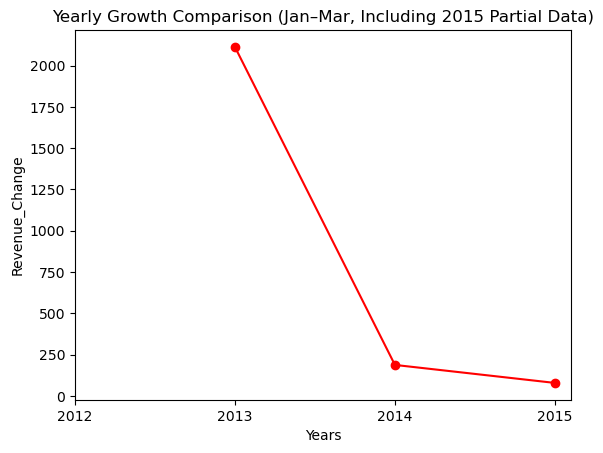

In [35]:
plt.plot(orders_compare['year'],orders_compare['change'],color = 'red',marker = 'o')
plt.xticks(orders_compare['year'])
plt.xlabel('Years')
plt.ylabel('Revenue_Change')
plt.title('Yearly Growth Comparison (Jan–Mar, Including 2015 Partial Data)')
plt.show()

In [36]:
orders_compare

,year,revenue,previous_revenue,change
0,2012,2999.40,NaN,NaN
1,2013,66377.27,2999.40,2113.018270
2,2014,190771.14,66377.27,187.404318
3,2015,340375.55,190771.14,78.420882


In [37]:
#### orders by year for comparision analysis 
### 2015 having partial data of the months 1,2,3 so taken 3 months data for all years for comparision 

In [38]:
orders_year_month = orders.groupby(['year','month'])['order_id'].count().reset_index(name = 'order_counts')

# Yearly Wise Orders Change 

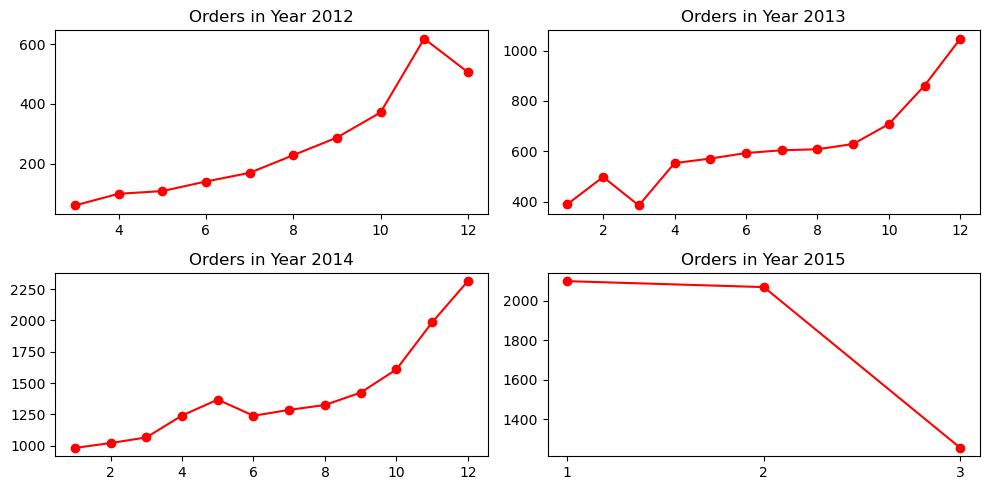

In [39]:
fig,axes = plt.subplots(2,2,figsize =(10,5))

order_2012 = orders_year_month[orders_year_month['year'] == 2012]
axes[0,0].plot(order_2012['month'],order_2012['order_counts'],marker = 'o',color = 'red')
axes[0,0].set_title('Orders in Year 2012')

order_2013 = orders_year_month[orders_year_month['year'] == 2013]
axes[0,1].plot(order_2013['month'],order_2013['order_counts'],marker = 'o',color = 'red')
axes[0,1].set_title('Orders in Year 2013')

order_2014 = orders_year_month[orders_year_month['year'] == 2014]
axes[1,0].plot(order_2014['month'],order_2014['order_counts'],marker = 'o',color = 'red')
axes[1,0].set_title('Orders in Year 2014')

order_2015 = orders_year_month[orders_year_month['year'] == 2015]
axes[1,1].plot(order_2015['month'],order_2015['order_counts'],marker = 'o',color = 'red')
axes[1,1].set_xticks(order_2015['month'])
axes[1,1].set_title('Orders in Year 2015')

plt.tight_layout()


In [40]:
orders_volume_month_year = orders.groupby('year_month')['order_id'].count().reset_index(name = 'Sales_Volume')
orders_volume_month_year.to_csv('orders_volume_month_year.csv',index = False)

# Monthly Order counts & Order_Revenue Comparision

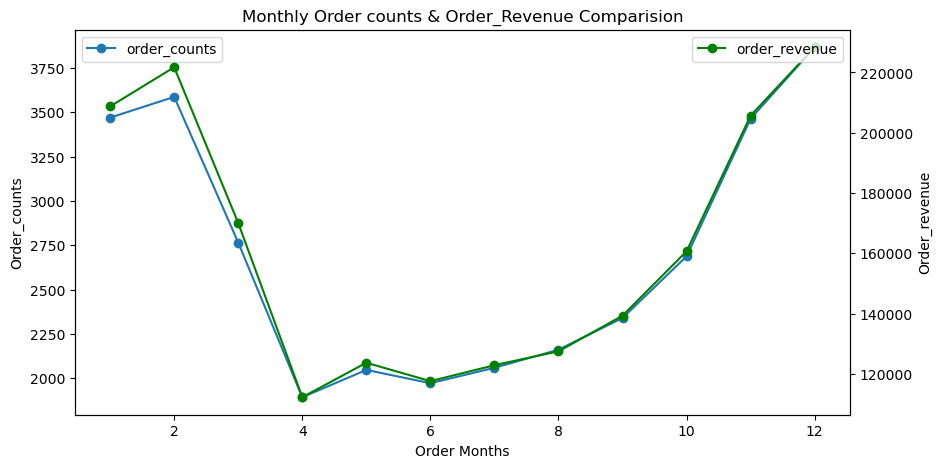

In [41]:
#### Monthly change in orders counts and revenue 

orders_counts_revenue = orders.groupby('month').agg(order_counts =('order_id','count'),revenue = ('price_usd','sum')).reset_index()

fig,axes = plt.subplots(figsize =(10,5))

axes.plot(orders_counts_revenue['month'],orders_counts_revenue['order_counts'],marker = 'o',label = 'order_counts')
axes.legend()
axes.set_xlabel('Order Months')
axes.set_ylabel('Order_counts')

axes1 = axes.twinx()
axes1.plot(orders_counts_revenue['month'],orders_counts_revenue['revenue'],marker = 'o',label = 'order_revenue',color = 'green')
axes1.set_ylabel('Order_revenue')
axes.set_title('Monthly Order counts & Order_Revenue Comparision')
axes1.legend(loc = 'upper right')
plt.show()

In [42]:
#### Month 6 is a growth take off month this is the month from where the orders traffic is going to increase 
#### There is a seasonal dip in month of march (3)
#### Month 11,12 can be considered as a peak months 
#### Month 4 are having lowest orders and revenue 
#### Month of 12 having highest orders and revenues

In [43]:
order_item_refunds['created_at'] = pd.to_datetime(order_item_refunds['created_at'])
order_items['created_at'] = pd.to_datetime(order_items['created_at'])

In [44]:
######## The growth rate is getting decreased in year 2014 compared to 2013 
### the orders,revenue,items_increased is still increasing continuously the reduce is just due to the base effect rather than effect of 
### operational issues the growth rate in 2014 is bit slow comapred to year 2013 

In [45]:
products['created_at'] = pd.to_datetime(products['created_at'])

In [46]:
#### Monthly Conversion Rate

In [47]:
website_sessions['created_at'] = pd.to_datetime(website_sessions['created_at'])

C:\Users\Harshita Sahu\AppData\Local\Temp\ipykernel_3248\2589124996.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  website_sessions['created_at'] = pd.to_datetime(website_sessions['created_at'])


In [48]:
orders_website_sessions = pd.merge(website_sessions,orders, on = 'website_session_id',how = 'left')

In [49]:
import numpy as np

# Monthly_Conversion_Rate & Session Counts

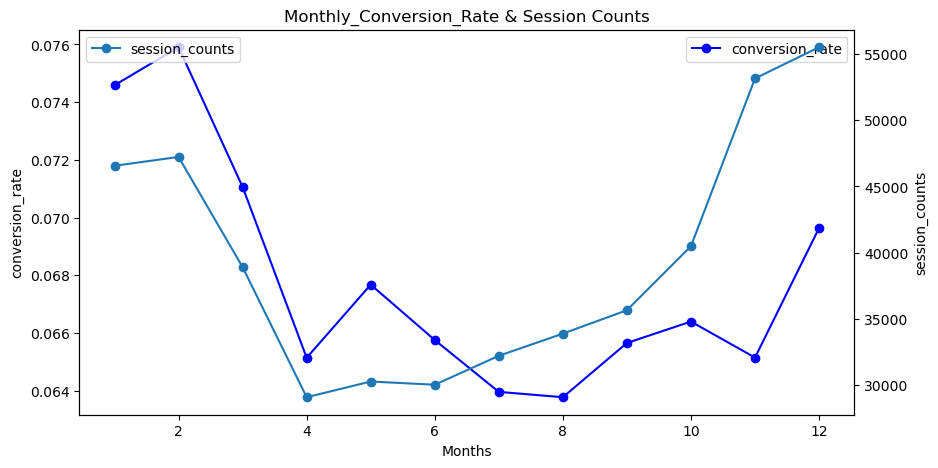

In [50]:
orders_website_sessions['session_months'] = orders_website_sessions['created_at_x'].dt.month
Monthly_Convesion_rate = orders_website_sessions.groupby('session_months')['order_id'].apply(lambda x :x.notna().mean())
orders_session_counts = orders_website_sessions.groupby('session_months')['website_session_id'].count().reset_index(name = 'session_counts')
Monthly_Convesion_rate = Monthly_Convesion_rate.reset_index(name = 'conversion_rate')
fig,axes = plt.subplots(figsize =(10,5))

axes.plot(Monthly_Convesion_rate['session_months'],Monthly_Convesion_rate['conversion_rate'],marker = 'o',color = 'b',label = 'conversion_rate')
axes.set_xlabel('Months')
axes.legend(loc = 'upper right')
axes.set_ylabel('conversion_rate')
plt.title('Monthly_Conversion_Rate & Session Counts')


axes1 = axes.twinx()
axes1.plot(orders_session_counts['session_months'],orders_session_counts['session_counts'],marker = 'o',label = 'session_counts')
axes1.legend()
axes1.set_ylabel('session_counts')
axes1.legend()

plt.show()

In [51]:
monthly_orders_sessions =  pd.merge(Monthly_Convesion_rate,orders_session_counts,on = 'session_months',how = 'left')
monthly_orders_sessions.to_csv('monthly_orders_sessions.csv',index = False)

In [52]:
### Month of Feb having the highest conversions 
### In month of 11,12 there highest session counts are there but if we compare with its
### conversion rate are low which means largely the customers are not buying just scrolling
### In month of 4 there is dip in both conversion and session counts

##Month 11–12:more visitors,browsing heavy,lower intent %
##Month 2:fewer visitors,targeted/returning,higher intent %
### Month 2 having higher conversion rate as the repeat customers are also high here 

In [53]:
##### Waterfall Analysis 
Total_orders = orders['order_id'].count()
Total_Cost = orders['cogs_usd'].sum()
Total_Revenue = orders['price_usd'].sum()
Total_Refunded_Amt = order_item_refunds['refund_amount_usd'].sum()
Refunded_items_Cost = pd.merge(order_items,order_item_refunds,how = 'right',on = 'order_item_id')['cogs_usd'].sum()
Total_Net_Revenue = Total_Revenue - Total_Refunded_Amt
Total_Net_Cost = Total_Cost - Refunded_items_Cost
Profit = Total_Net_Revenue - Total_Net_Cost

In [54]:
waterfall_analysis = pd.DataFrame({'Step':['Total_Revenue','Total_Cost','Total_Refunded_Amt','Refunded_items_cost','Profit'],'Amount':[Total_Revenue,-Total_Cost,Total_Refunded_Amt,-Refunded_items_Cost,Profit]})

In [55]:
waterfall_analysis

,Step,Amount
0,Total_Revenue,1938509.75
1,Total_Cost,-722370.25
2,Total_Refunded_Amt,85338.69
3,Refunded_items_cost,-31979.19
4,Profit,1162780.00


In [56]:
waterfall_analysis['Cumulative'] = waterfall_analysis['Amount'].cumsum()

In [57]:
waterfall_analysis.to_csv('waterfall_analysis.csv',index = False)

# WaterFall Analysis 

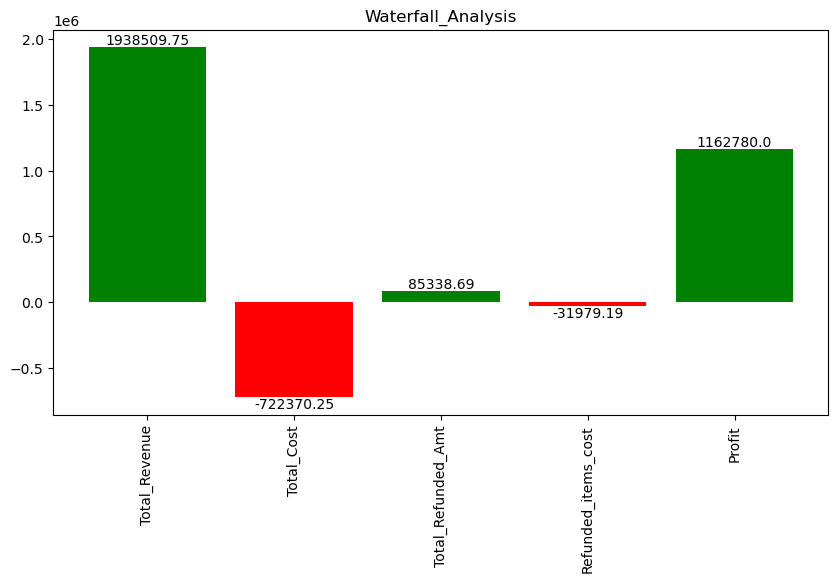

In [58]:
fig,ax = plt.subplots(figsize =(10,5))
plt.title('Waterfall_Analysis')
colorss = ['green' if x>0  else 'red' for x in waterfall_analysis['Amount']]
ax.bar(waterfall_analysis['Step'],waterfall_analysis['Amount'],color = colorss)
plt.xticks(waterfall_analysis['Step'],rotation = 90)

for i,val in enumerate(waterfall_analysis['Amount']):
    if val>=0 :
        ax.text(i,val,round(val,2),ha = 'center' , va = 'bottom')
    else:
        ax.text(i,val,round(val,2),ha = 'center' , va = 'top')

plt.show()

In [59]:
### it shows how the money actually flowing in which Total_cost contributes the most but 

In [60]:
gross_margin = (Total_Revenue - Total_Cost)*100.00/Total_Revenue
gross_margin

62.73579485478472

In [61]:
refunded_rate = (Total_Refunded_Amt)*100.00/Total_Revenue
refunded_rate

4.402283248768803

In [62]:
profit_margin = (Profit/Total_Revenue)*100.00
profit_margin

59.983190695842524

In [63]:
##The business having strong gross margin it is 62% before deducting refunds and other stuff 
##the refund rate is 4.4% which is very low 
##the business selling the products at high margin as its profit margin is about 60%

In [64]:
#### Revenue Decline Analysis 
order_refundsss = pd.merge(order_items,order_item_refunds,how = 'left' , on = 'order_item_id',suffixes= ('_order_items','_order_refunds'))

In [65]:
orders_revenue = orders.groupby('month')['price_usd'].sum().reset_index(name = 'revenue')

In [66]:
orders_revenue['previous_revenue'] = orders_revenue['revenue'].shift(1)

In [67]:
orders_revenue['revenue_%_change'] =(orders_revenue['revenue'] - orders_revenue['previous_revenue'])*100.00 / orders_revenue['previous_revenue']

# Month - Over - Month Revenue % Change

posx and posy should be finite values
posx and posy should be finite values


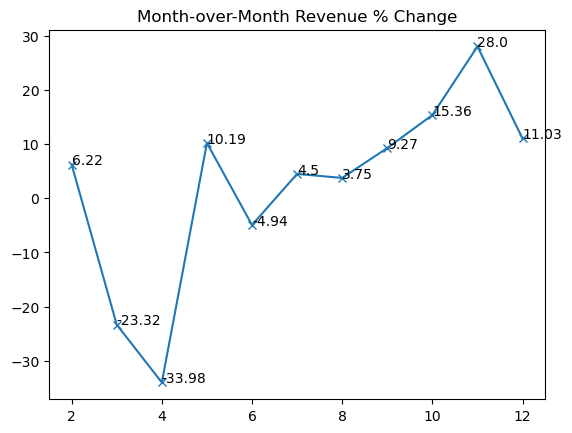

In [68]:
plt.plot(orders_revenue['month'],orders_revenue['revenue_%_change'],marker = 'x')
for x,y in zip(orders_revenue['month'],orders_revenue['revenue_%_change']):
    plt.text(x,y,str(round(y,2)))

plt.title('Month-over-Month Revenue % Change')
plt.show()

In [69]:
### here the revenue decline is seasonal not structural 

In [70]:
order_item_refunds['created_at'] = pd.to_datetime(order_item_refunds['created_at'])

In [71]:
order_item_refunds['year'] = order_item_refunds['created_at'].dt.year
order_item_refunds['month'] = order_item_refunds['created_at'].dt.month

In [72]:
order_item_refunds['month'] = order_item_refunds['created_at'].dt.month

In [73]:
order_items['created_at'] = pd.to_datetime(order_items['created_at'])
order_items['year'] = order_items['created_at'].dt.year
order_items['month'] = order_items['created_at'].dt.month

In [74]:
orders_items_order_refund = pd.merge(order_items,order_item_refunds,on = 'order_item_id' ,how = 'left',suffixes= ('_order_items','_order_items_refund'))

In [75]:
##### calculating profitss 
orders_items_order_refund['profit'] = (orders_items_order_refund['price_usd'] - np.where(orders_items_order_refund['order_item_refund_id'].notna() 
 ,orders_items_order_refund['refund_amount_usd'] , 0))-(orders_items_order_refund['cogs_usd'] - np.where(orders_items_order_refund['order_item_refund_id']
                                 .notna(), orders_items_order_refund['cogs_usd'], 0))

In [76]:
orders_items_order_refund_profitsss= orders_items_order_refund.groupby(['month_order_items','year_order_items'])['profit'].sum().reset_index(name = 'Profit')
orders_items_order_refund_profitsss = orders_items_order_refund_profitsss.sort_values(['month_order_items','year_order_items',])
orders_items_order_refund_profitsss['pct_change'] = orders_items_order_refund_profitsss.groupby('year_order_items')['Profit'].pct_change()
orders_items_order_refund_profitsss
#orders_items_order_refund_profit['previous_year_profit'] = orders_items_order_refund_profit['Profit'].shift(1)
#orders_items_order_refund_profit['profit_prct']= ((orders_items_order_refund_profit['Profit']-orders_items_order_refund_profit['previous_year_profit'])*100.00
 #                                                 /orders_items_order_refund_profit['previous_year_profit'])

,month_order_items,year_order_items,Profit,pct_change
0,1,2013,11668.0,NaN
1,1,2014,33861.5,NaN
2,1,2015,80861.5,NaN
3,2,2013,15516.0,0.329791
4,2,2014,40353.5,0.191722
5,2,2015,79610.0,-0.015477
6,3,2012,1799.5,NaN
7,3,2013,11536.0,-0.256509
8,3,2014,41668.0,0.032575
9,3,2015,48312.0,-0.393142


In [77]:
##profit_year_month = orders_items_order_refund.groupby('year_month')[['profit','price_usd']].sum().reset_index()
## profit_year_month['profit_margin'] = profit_year_month['profit']/profit_year_month['price_usd']*100.00
##profit_year_month.to_csv('profit_year_month.csv',index = False)

In [78]:
orders_items_order_refund['quarters'] = orders_items_order_refund['created_at_order_items'].dt.quarter

In [79]:
orders_items_order_refund.groupby(['year_order_items','quarters'])['order_id_order_items'].nunique()

year_order_items  quarters
2012              1             60
                  2            347
                  3            684
                  4           1495
2013              1           1273
                  2           1717
                  3           1841
                  4           2616
2014              1           3069
                  2           3848
                  3           4035
                  4           5908
2015              1           5420
Name: order_id_order_items, dtype: int64

In [80]:

quarter_summary = orders_items_order_refund.groupby(['year_order_items','quarters']).agg(Profit = ('profit','sum'),Revenue = ('price_usd','sum'),Sales_Volume=('order_id_order_items','nunique'))
quarter_summary = quarter_summary.reset_index()
quarter_summary.to_csv('quarter_summary.csv',index = False)

In [81]:
quarter_summary

,year_order_items,quarters,Profit,Revenue,Sales_Volume
0,2012,1,1799.5,2999.40,60
1,2012,2,10065.0,17346.53,347
2,2012,3,19123.5,34193.16,684
3,2012,4,42456.0,74735.05,1495
4,2013,1,38720.0,66377.27,1273
5,2013,2,51216.0,88492.83,1717
6,2013,3,55499.0,95241.53,1841
7,2013,4,85700.5,143136.24,2616
8,2014,1,115883.0,190771.14,3069
9,2014,2,150545.0,247711.95,3848


In [82]:
quarter_summary_sort = quarter_summary.sort_values(['quarters','year_order_items'])
quarter_summary_sort['Previous_Year_Profit'] = quarter_summary_sort.groupby('quarters')['Profit'].shift(1)
quarter_summary_sort['Prcnt_change_Profit'] = (quarter_summary_sort['Profit']-quarter_summary_sort['Previous_Year_Profit'])*100.00/quarter_summary_sort['Previous_Year_Profit']
quarter_summary_sort

,year_order_items,quarters,Profit,Revenue,Sales_Volume,Previous_Year_Profit,Prcnt_change_Profit
0,2012,1,1799.5,2999.40,60,NaN,NaN
4,2013,1,38720.0,66377.27,1273,1799.5,2051.708808
8,2014,1,115883.0,190771.14,3069,38720.0,199.284607
12,2015,1,208783.5,340375.55,5420,115883.0,80.167497
1,2012,2,10065.0,17346.53,347,NaN,NaN
5,2013,2,51216.0,88492.83,1717,10065.0,408.852459
9,2014,2,150545.0,247711.95,3848,51216.0,193.941346
2,2012,3,19123.5,34193.16,684,NaN,NaN
6,2013,3,55499.0,95241.53,1841,19123.5,190.213612
10,2014,3,152247.5,260237.12,4035,55499.0,174.324763


In [83]:
#### considering year 2012,2013,2014 only as 2015 does not having full data 
orders_items_order_refund_year_wise = orders_items_order_refund[orders_items_order_refund['year_order_items'].isin([2012,2013,2014])]

orders_items_order_refund_profit_year  = orders_items_order_refund_year_wise.groupby('year_order_items')['profit'].sum().reset_index(name = 'Profit')
orders_items_order_refund_profit_year['previous_year_profit'] = orders_items_order_refund_profit_year['Profit'].shift(1)
orders_items_order_refund_profit_year['profit_prct']= ((orders_items_order_refund_profit_year['Profit']-orders_items_order_refund_profit_year['previous_year_profit'])*100.00/orders_items_order_refund_profit_year['previous_year_profit'])

In [84]:
orders_items_order_refund_profit_year

,year_order_items,Profit,previous_year_profit,profit_prct
0,2012,73444.0,NaN,NaN
1,2013,231135.5,73444.0,214.709847
2,2014,649417.0,231135.5,180.968090


In [85]:
orders_items_order_refund_profit_year.to_csv('profit_prct_change.csv',index = False)

# Year_wise_profit_prct_change%

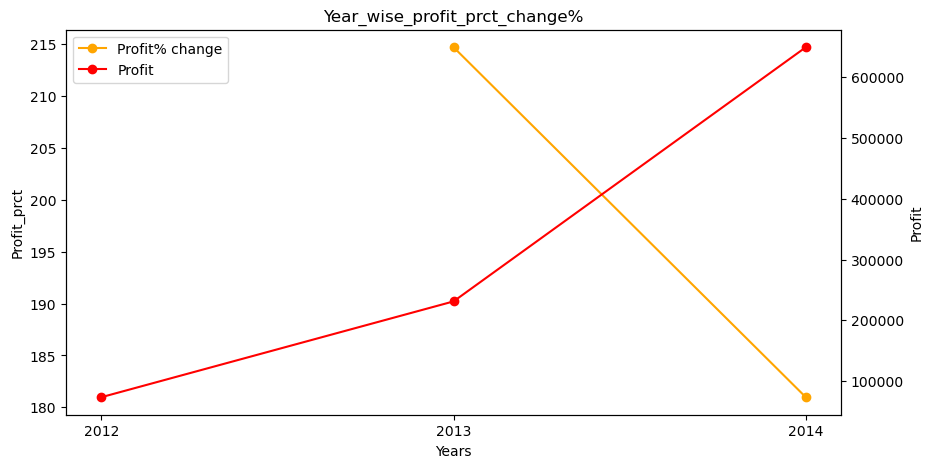

In [86]:
#### year wise profit growth 
###  year wise profit growth change so like it is going down the reason behind it that the growth is slow down compare in 
### 2013 to year 2014 the profit has been increased by +180% from the last year but in case of growth it has been decreased 
### The growth is slow

fig,axes = plt.subplots(figsize = (10,5))

line1, = axes.plot(orders_items_order_refund_profit_year['year_order_items'],orders_items_order_refund_profit_year['profit_prct'],color = 'orange',marker = 'o'
         ,label = 'Profit% change')
axes.set_title('Year_wise_profit_prct_change%')
axes.set_xticks(orders_items_order_refund_profit_year['year_order_items'])
axes.set_xlabel('Years')
axes.set_ylabel('Profit_prct')

axes_1  = axes.twinx()
line2, = axes_1.plot(orders_items_order_refund_profit_year['year_order_items'],orders_items_order_refund_profit_year['Profit'],color = 'red',marker = 'o'
                    ,label = 'Profit')
###axes_1.set_title('Year_wise_profit')
###axes_1.set_xticks(orders_items_order_refund_profit_year['year_order_items'])
axes_1.set_ylabel('Profit')

lines = [line1,line2]
labels = [line.get_label() for line in lines]

axes.legend(lines,labels,loc = 'upper left')

plt.show()


In [87]:

profit_margin = orders_items_order_refund_year_wise.groupby('year_order_items')[['price_usd','profit']].sum().reset_index()

In [88]:
profit_margin['profit_margins'] = (profit_margin['profit']/profit_margin['price_usd'])*100.0

In [89]:
### why the growth rate of profit is slow reason behind it 
#Revenue and profit continued to grow strongly in 2014, with improving profit margins. 
#The decline in year-over-year growth rate appears to be primarily due to the base effect 
##rather than operational inefficiencies.

In [90]:
###There is a very low correlation (0.012) between price and order volume, 
### indicates that price is not the driver force for the purchase of customer
### there are other factors which can influence the purchase beahviour of customer 

In [91]:
order_item_refunds

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd,year,month
0,1,2012-04-06 11:32:43,57,57,49.99,2012,4
1,2,2012-04-13 01:09:43,74,74,49.99,2012,4
2,3,2012-04-15 07:03:48,71,71,49.99,2012,4
3,4,2012-04-17 20:00:37,118,118,49.99,2012,4
4,5,2012-04-22 20:53:49,116,116,49.99,2012,4
...,...,...,...,...,...,...,...
1726,1727,2015-03-30 09:37:23,39950,32255,59.99,2015,3
1727,1728,2015-03-30 21:33:51,39671,32049,49.99,2015,3
1728,1729,2015-03-31 19:59:48,39729,32090,49.99,2015,3
1729,1730,2015-04-01 03:54:48,39717,32079,59.99,2015,4


# Correlation btw price & orders

Text(0.5, 1.0, 'Correlation btw price & orders')

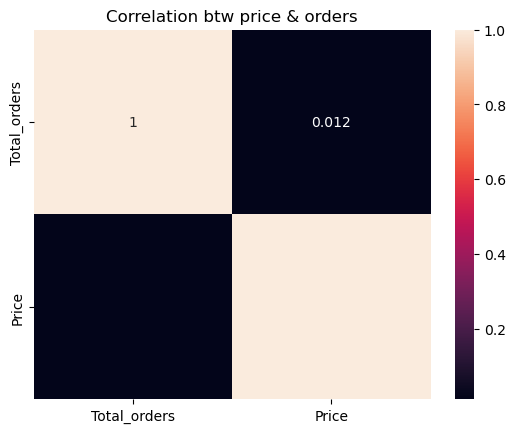

In [92]:
orders_corr = orders.groupby('user_id').agg(Total_orders = ('order_id','count'),Price = ('price_usd','mean')).corr()
import seaborn as sns
sns.heatmap(orders_corr,annot = True)
plt.title('Correlation btw price & orders')

# Correlation btw price & orders

Text(0.5, 1.0, 'Correlation btw price & orders')

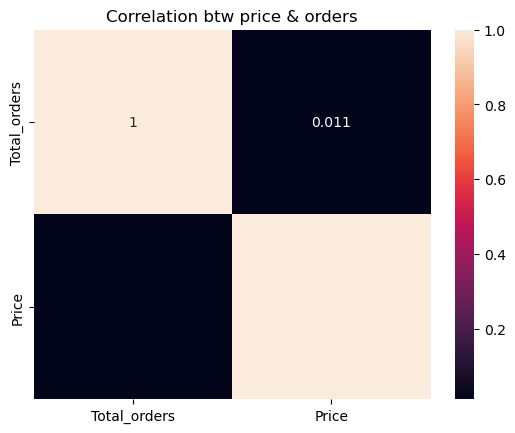

In [93]:
orders_corr = orders.groupby('user_id').agg(Total_orders = ('order_id','count'),Price = ('price_usd','median')).corr()
import seaborn as sns
sns.heatmap(orders_corr,annot = True)
plt.title('Correlation btw price & orders')

# Correlation btw items purchased & revenue

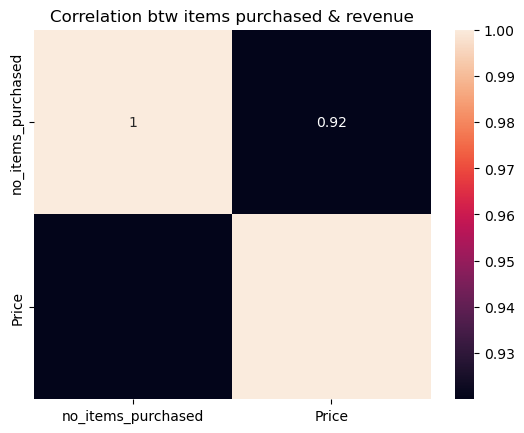

In [94]:
orders_order_items = orders.groupby('user_id').agg(no_items_purchased = ('items_purchased','mean'),Price = ('price_usd','mean')).corr()
sns.heatmap(orders_order_items,annot = True)
plt.title('Correlation btw items purchased & revenue')
plt.show()

In [95]:
#### Correlation btw items purchased & revenue is very strong about 0.92 as corr 
### that means our overall business is driven by volume not by the price as price is not influencing it much  

In [96]:
import seaborn as sns

# Correlation between order_counts & Price_usd

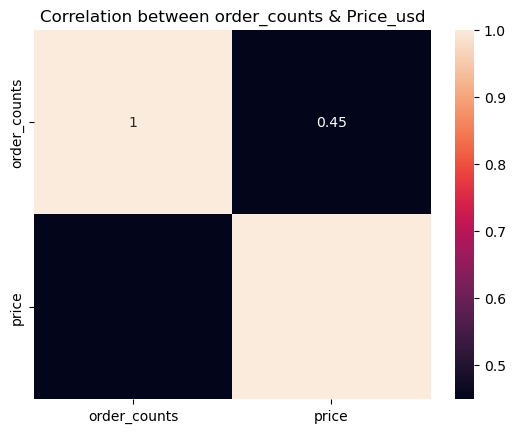

In [97]:

price_analysis_corr = orders.groupby('user_id').agg(order_counts = ('order_id','count'),price = ('price_usd','sum')).corr()
plt.title('Correlation between order_counts & Price_usd')
sns.heatmap(price_analysis_corr,annot = True)
plt.show()

In [98]:
#### Segmentizing cutomer as One-Time Customer , Repeat Customer & New Customer
### customer who have ordered one time they are one_time_cust 
### customer who have ordered multiple time they are repeat_cust
### customer who have ordered in its customer_lifetime<=30 then 'new_cust' 

customer_life_time = orders.groupby('user_id')['created_at'].max() - orders.groupby('user_id')['created_at'].min()

In [99]:
customers_data = orders.groupby('user_id').agg(Total_Orders = ('order_id','count'),first_order_date = ('created_at','min'),last_order_date = ('created_at','max')).reset_index()

In [100]:
customers_data['cust_life_time_days'] = (customers_data['last_order_date'] - customers_data['first_order_date']).dt.days

In [101]:
customers_data['order_type'] = customers_data['Total_Orders'].apply(lambda x:'One_Time_Customer' if x ==1 else 'Repeat_Customer')

In [102]:
customers_data['cust_type'] = customers_data['cust_life_time_days'].apply(lambda x:'New_Customer' if x <=30 else 'Existing_Customer')

In [103]:
#### Repeat Rate 
(customers_data[customers_data['order_type'].isin(['Repeat_Customer'])]['user_id'].count())*100.00/ customers_data['order_type'].count()

1.8645885916203937

In [104]:
cust_type_seg = customers_data.groupby('cust_type')['user_id'].count().reset_index()
cust_type_seg

,cust_type,user_id
0,Existing_Customer,306
1,New_Customer,31390


In [105]:
order_type_seg = customers_data.groupby('order_type')['user_id'].count().reset_index()
order_type_seg

,order_type,user_id
0,One_Time_Customer,31105
1,Repeat_Customer,591


# Customer_Type_Distributions

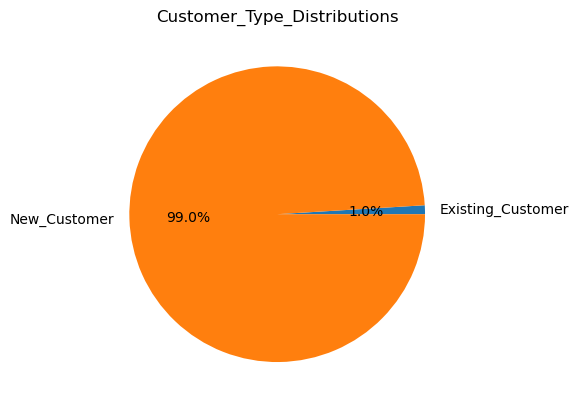

In [106]:
plt.title('Customer_Type_Distributions')
plt.pie(cust_type_seg['user_id'] ,labels = cust_type_seg['cust_type'],autopct = '%1.1f%%')
plt.show()

# Order_Type_Distributions

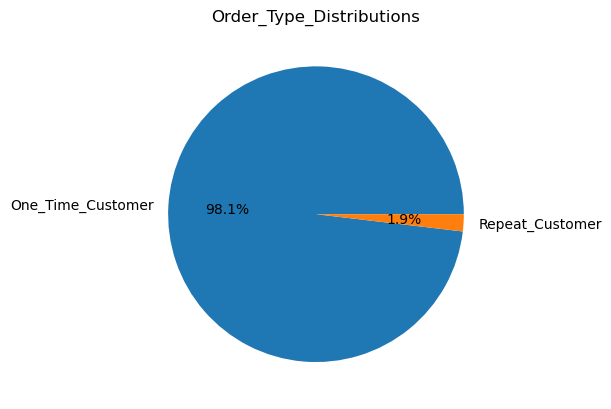

In [107]:
plt.title('Order_Type_Distributions')
plt.pie(order_type_seg['user_id'] ,labels = order_type_seg['order_type'],autopct = '%1.1f%%')
plt.show()

In [108]:
#### the business largely running due to one time customer which means that business not able to gain customer loyalty
###  Customer Acquistion is strong but in order to retain those customer it is very low 

In [109]:
month_wise_cust_seg = pd.merge(orders,customers_data,on = 'user_id',how = 'left')

In [110]:
#### Customer_Type by order_type dist
Monthly_order_type = month_wise_cust_seg.groupby(['month','order_type'])['order_type'].count().reset_index(name = 'user_counts')
Monthly_order_type

,month,order_type,user_counts
0,1,One_Time_Customer,3315
1,1,Repeat_Customer,155
2,2,One_Time_Customer,3434
3,2,Repeat_Customer,153
4,3,One_Time_Customer,2676
5,3,Repeat_Customer,89
6,4,One_Time_Customer,1822
7,4,Repeat_Customer,71
8,5,One_Time_Customer,1969
9,5,Repeat_Customer,78


In [111]:
monthly_order_pivot = Monthly_order_type.pivot(columns  = 'order_type' , index = 'month' , values = 'user_counts')

# Monthly Order Type Distributions

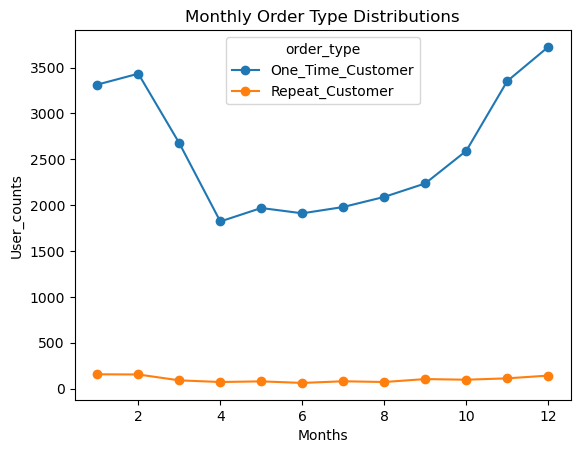

In [112]:
monthly_order_pivot.plot(marker='o')
plt.title('Monthly Order Type Distributions')
plt.xlabel('Months')
plt.ylabel('User_counts')
plt.show()

In [113]:
### New customers & One time customer are high in month dec there is accquring of new customer in that month
### repeat customer are high in month of feb that's why the conversion rate is also high in that month

In [114]:
#### Customer_Type by order_type dist
Monthly_cust_type = month_wise_cust_seg.groupby(['month','cust_type'])['cust_type'].count().reset_index(name = 'user_counts')
Monthly_cust_type

,month,cust_type,user_counts
0,1,Existing_Customer,74
1,1,New_Customer,3396
2,2,Existing_Customer,74
3,2,New_Customer,3513
4,3,Existing_Customer,50
5,3,New_Customer,2715
6,4,Existing_Customer,39
7,4,New_Customer,1854
8,5,Existing_Customer,35
9,5,New_Customer,2012


In [115]:
monthly_cust_pivot = Monthly_cust_type.pivot(columns  = 'cust_type' , index = 'month' , values = 'user_counts')
monthly_cust_pivot

cust_type,Existing_Customer,New_Customer
month,,
1,74,3396
2,74,3513
3,50,2715
4,39,1854
5,35,2012
6,30,1942
7,40,2019
8,40,2121
9,59,2281


# Monthly Customer Type Distributions

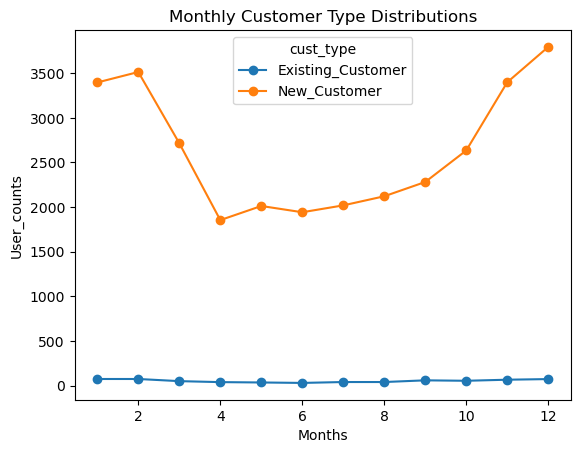

In [116]:
monthly_cust_pivot.plot(marker='o')
plt.title('Monthly Customer Type Distributions')
plt.xlabel('Months')
plt.ylabel('User_counts')
plt.show()

In [117]:
max_order_date = orders['created_at'].dt.normalize().max()
customers_data['last_order_date_'] = customers_data['last_order_date'].dt.normalize()

In [118]:
customers_data['days_after_last_purchase'] = (max_order_date - customers_data['last_order_date_']).dt.days

In [119]:
customers_data[customers_data['order_type']=='One_Time_Customer']['cust_life_time_days'].mean()

0.0

In [120]:
customers_data[customers_data['order_type']=='Repeat_Customer']['cust_life_time_days'].mean()

35.50592216582064

In [121]:
##Repeat customers typically make subsequent purchases within about 35 days of their first purchase,
##indicating a roughly one-month repeat 
##cycle. In contrast, one-time customers show zero lifetime span because they do not return for additional purchases.
## the repeat cycle is about of 35 days (business can give reminders after 28-30 days) in order to increase repeat rate 
### the most likely the customer who made puchase in month of jan are returning in feb to make puchases 
### that's why the return customers and conversion rate is high in that month

In [122]:
##The business shows a repeat purchase cycle of about 35 days. 
##Customers who purchase in one month, particularly January, are likely to return in the following month
##(February), leading to higher repeat share and conversion rates. Repeat activity is
##especially concentrated in months such as Jan, Feb, Sep, Nov, and Dec, indicating seasonal
##retention peaks aligned with the ~30-day repeat window.

In [123]:
customers_data['cust_lifetime_score'] = customers_data['cust_life_time_days'].apply(lambda x:0 if ((x>=0) & (x<=30)) else 40 if ((x>30) & (x<=60)) else
                                            60 if ((x>60) & (x<=90)) else 100 if x>90 else None)

customers_data['cust_lifetime_score'] = customers_data['cust_lifetime_score'].astype('int')

customers_data['days_after_last_purchase_score'] =  customers_data['days_after_last_purchase'].apply(lambda x:80 if ((x>=0) & (x<=365)) else 20 if ((x>=366) & (x<=730)) else
                                            0 if x>=731 else None )

customers_data['days_after_last_purchase_score'] = customers_data['days_after_last_purchase_score'].astype('int')

customers_data['customer_lifetime_&_last_purchase_score'] = customers_data['cust_lifetime_score'] + customers_data['days_after_last_purchase_score']
customers_data['customer_lifetime_&_last_purchase_score'] = customers_data['customer_lifetime_&_last_purchase_score'].astype('int')

customers_data['cust_retention_type'] = customers_data['customer_lifetime_&_last_purchase_score'].apply(lambda x:'Risk' if x<=40 else 'Active' if ((x>40) & (x<=80)) else 'Best' )

In [124]:
customers_data['cust_retention_type'].unique()

array(['Risk', 'Active', 'Best'], dtype=object)

In [125]:
cust_retention_type = customers_data.groupby('cust_retention_type')['user_id'].count().reset_index(name = 'user_counts')

In [126]:
cust_retention_type

,cust_retention_type,user_counts
0,Active,19089
1,Best,221
2,Risk,12386


In [127]:
cust_retention_type['cust_retention_prcnt'] = (cust_retention_type['user_counts'])*100.00/cust_retention_type['user_counts'].sum()

# Customer Retention Analysis

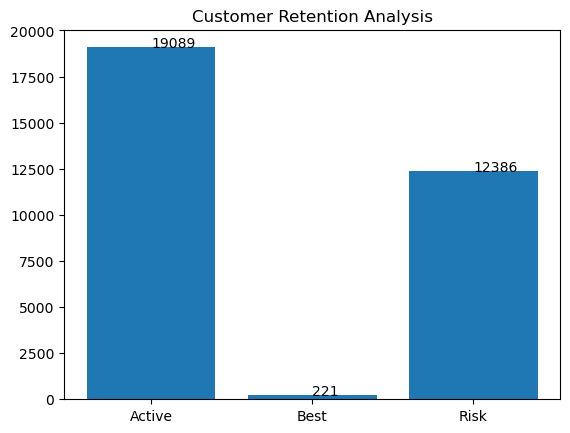

In [128]:
plt.title('Customer Retention Analysis')
bars= plt.bar(cust_retention_type['cust_retention_type'],cust_retention_type['user_counts'])
for i,val in enumerate(bars):
    height = val.get_height()
    plt.text(i,height+0.5,str(height))
plt.show()

In [129]:
##customer churn and retention analysis 
##Consider loyalty and recency taken the max portion of customer_lifetime max is 100 and then the second priority given to 
##recency max of 80 
##so the range is like best customer has to be around 180 (customer is old as well as recently purchased)
## the range btw 40 to 80 has to be active  (customer is old and purchase recently )
##less than 40 then it is risky( the customer is recent and not purchased recently )

In [130]:
### The customer is classified into 3 Active,Best & at Risk 
### The customer largely active about 60%
### The 40% of customer are risk who just left the business a long on 
### All this indicates one thing that customer are purchasing one_time largely and then they just left the business 
### The Business is very dependent on the paid traffic which is not good for the long_term & they are larlely depending 
### on constant aqusition of customer instead they very importantely need to take measure steps in order to retain customer 

In [131]:
orders['Order_Time_Bin'] = orders['created_at'].dt.hour.apply(lambda x:'Early_Morning' if ((x>=0) & (x<=5)) else 'Morning' if ((x>=6) & (x<=11)) else 
                           'Afternoon' if ((x>=12) & (x<=16)) else 'Evening' if ((x>=17) & (x<=20)) else 'Night')

In [132]:
orders['Day_Bin']  = orders['created_at'].dt.day_name().apply(lambda x:'Weekend' if x == 'Saturday' else 'Weekend' if x == 'Sunday' else 'Weekdays')

In [133]:
Order_time_dist = orders.groupby('Order_Time_Bin')['order_id'].count().reset_index(name = 'Total_Orders')

In [134]:
Order_time_dist

,Order_Time_Bin,Total_Orders
0,Afternoon,10697
1,Early_Morning,3791
2,Evening,6082
3,Morning,8392
4,Night,3351


In [135]:
Order_time_dist.to_csv('Order_time_dist.csv',index = False)

# Total Orders Distribution by Time Buckets

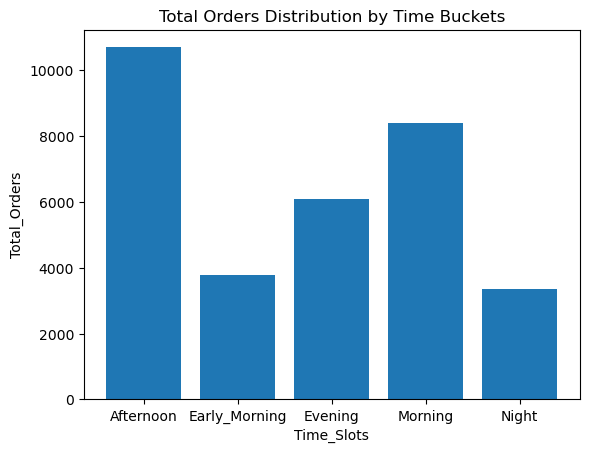

In [136]:
### Number of orders by Order Time Bin
plt.title('Total Orders Distribution by Time Buckets')
plt.bar(Order_time_dist['Order_Time_Bin'] , Order_time_dist['Total_Orders'])
plt.xlabel('Time_Slots')
plt.ylabel('Total_Orders')
plt.show()

In [137]:
### Number of orders are largely being order in Afternoon and then in Morning 
### and least at night as well the customer 

In [138]:
website_sessions['Time_Slots'] = website_sessions['created_at'].dt.hour.apply(lambda x:'Early_Morning' if ((x>=0) & (x<=5)) else 'Morning' if ((x>=6) & (x<=11)) else 
                           'Afternoon' if ((x>=12) & (x<=16)) else 'Evening' if ((x>=17) & (x<=20)) else 'Night')

In [139]:
website_session_orders_time = pd.merge(website_sessions,orders,on = 'website_session_id',how = 'left',suffixes=  ('_website','_orders'))

In [140]:
Website_Time_wise_Conversion_rate = (website_session_orders_time.groupby('Time_Slots')['order_id'].apply(lambda x:x.notna().sum())/website_session_orders_time.groupby('Time_Slots')['website_session_id'].nunique()).reset_index(name = 'Time_wise_conversion_rate')

In [141]:
Website_Time_wise_Conversion_rate

,Time_Slots,Time_wise_conversion_rate
0,Afternoon,0.068833
1,Early_Morning,0.067766
2,Evening,0.067985
3,Morning,0.068307
4,Night,0.068065


In [142]:
Website_Time_wise_Conversion_rate.to_csv('Website_Time_wise_Conversion_rate.csv',index = False)

# Time Wise Conversion Rate

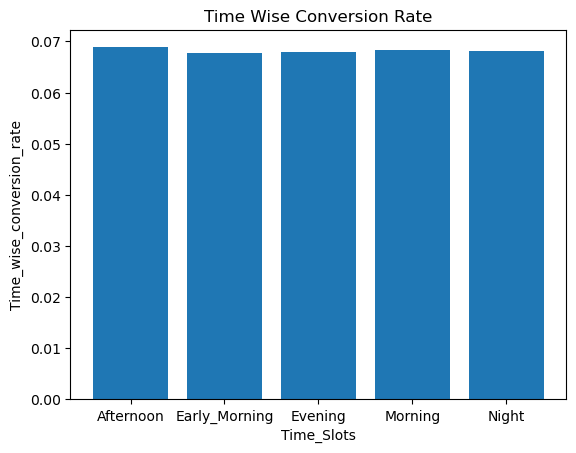

In [143]:
### Number of orders by Order Time Bin
plt.title('Time Wise Conversion Rate')
plt.bar(Website_Time_wise_Conversion_rate['Time_Slots'] , Website_Time_wise_Conversion_rate['Time_wise_conversion_rate'])
plt.xlabel('Time_Slots')
plt.ylabel('Time_wise_conversion_rate')
plt.show()

In [144]:
#### Although the Traffic is high in afternoon as well as most order are lie in afternoon but in case of conversion
### rate by sessions is stable which means there is no dramatic demand is time concantrated not urgency driven
### Buying intent is same accross day 
### The buying intent is same it is just that the traffic is high on website in afternoon that why the orders are sold more in that time frame
### We can run campians in that time frame to attract more traffic 
#### intent-neutral traffic growth

In [145]:
website_sessions.groupby('Time_Slots')['website_session_id'].count().reset_index(name = 'session_counts')

,Time_Slots,session_counts
0,Afternoon,155158
1,Early_Morning,54511
2,Evening,86504
3,Morning,128465
4,Night,48233


In [146]:
days_bin_dist = orders.groupby('Day_Bin')['order_id'].count().reset_index(name = 'Total_Orders')

In [147]:
days_bin_dist

,Day_Bin,Total_Orders
0,Weekdays,27466
1,Weekend,4847


# Total_Orders_Distributions By Day Bin

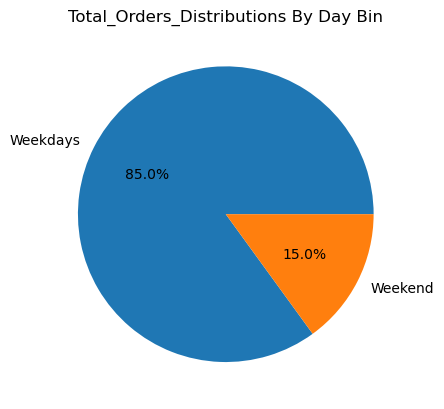

In [148]:
plt.title('Total_Orders_Distributions By Day Bin')
plt.pie(days_bin_dist['Total_Orders'],labels = days_bin_dist['Day_Bin'],autopct = '%1.1f%%')
plt.show()

In [149]:
days_bin_dist.to_csv('days_bin_dist.csv',index = False)

In [150]:
### Number of orders on Weekdays are high compare to Weekend

In [151]:
orders['Order_Hour'] = orders['created_at'].dt.hour

In [152]:
order_Hour = orders.groupby('Order_Hour')['order_id'].count().reset_index(name = 'No_of_orders')

# No of Orders by hour

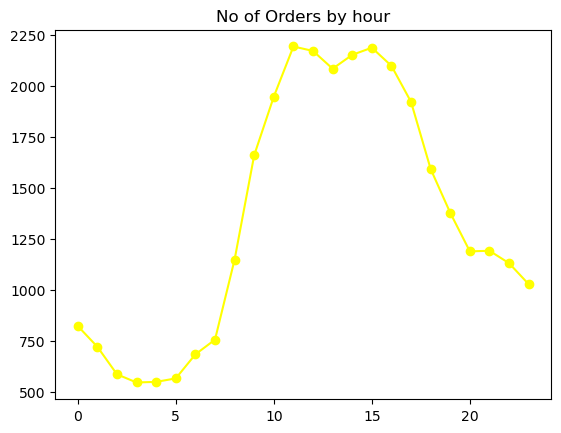

In [153]:
plt.title('No of Orders by hour')
plt.plot(order_Hour['Order_Hour'],order_Hour['No_of_orders'],marker = 'o',color = 'yellow')
plt.show()

In [154]:
### Peak hour of order is 11 and 12

In [155]:
order_Hour.to_csv('order_Hour.csv',index = False)

In [156]:
orders['Order_Day_Name'] = orders['created_at'].dt.day_name()

In [157]:
orders_by_day_name = orders.groupby('Order_Day_Name')['order_id'].count().reset_index(name = 'order_counts')

# No of Orders by Day_Name

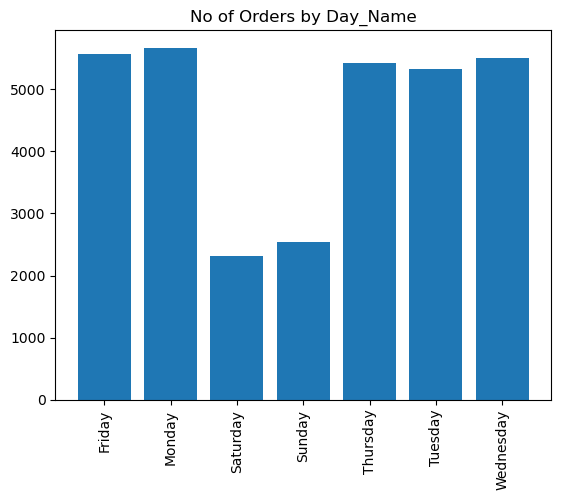

In [158]:
plt.bar(orders_by_day_name['Order_Day_Name'],orders_by_day_name['order_counts'])
plt.xticks(orders_by_day_name['Order_Day_Name'],rotation = 90)
plt.title('No of Orders by Day_Name')
plt.show()

In [159]:
orders_by_day_name.to_csv('orders_by_day_name.csv',index = False)

In [160]:

### Least orders on Saturday and highest on Monday

In [161]:
##### RFM analysis 
orders_order_item_refunds = pd.merge(orders,order_item_refunds,on = 'order_id',how = 'left',suffixes= ('_orders','order_item_refunds'))

In [162]:
orders_order_item_refunds['created_at_orders'].max()

Timestamp('2015-03-19 05:38:31')

In [163]:

orders_order_item_refunds['net_revenue'] = ((orders_order_item_refunds['price_usd']) - (np.where(orders_order_item_refunds['refund_amount_usd'].notna(),orders_order_item_refunds['refund_amount_usd'],0)))
max_order = orders_order_item_refunds['created_at_orders'].max()

rfm_analysis = orders_order_item_refunds.groupby('user_id').agg(Recency = ('created_at_orders'
                                                                           ,lambda x :(max_order -x.max()).days),Frequency = ('order_id','nunique'),Monetary = ('net_revenue','sum'))
rfm_analysis.reset_index(inplace = True)
rfm_analysis['Recency_Score'] = pd.qcut(rfm_analysis['Recency'],3,labels= [3,2,1])
rfm_analysis['Monetary_Score'] = pd.qcut(rfm_analysis['Monetary'],3,labels= [1,2,3])
rfm_analysis['Frequency_Score'] = pd.qcut(rfm_analysis['Frequency'].rank(method='first'),3,labels= [1,2,3])
rfm_analysis['Recency_Score'] = rfm_analysis['Recency_Score'].astype('int')
rfm_analysis['Monetary_Score'] = rfm_analysis['Monetary_Score'].astype('int')
rfm_analysis['Frequency_Score'] = rfm_analysis['Frequency_Score'].astype('int')
rfm_analysis['RFM_Score'] = rfm_analysis['Recency_Score']+rfm_analysis['Monetary_Score']+rfm_analysis['Frequency_Score']
rfm_analysis['RFM_Score'] = rfm_analysis['RFM_Score'].astype('int')
rfm_analysis['RFM_Segments'] = np.where(
rfm_analysis['RFM_Score'] >= 7,
    'High_Value_Cust',
    np.where(
        (rfm_analysis['RFM_Score']>=4) & (rfm_analysis['RFM_Score']<=6)   ,
        'Medium_Value_Cust',
        'Low_Value_Cust'
    )
)

In [164]:
rfm_segments = rfm_analysis.groupby('RFM_Segments')['user_id'].count().reset_index(name = 'user_counts')

In [165]:
rfm_segments

,RFM_Segments,user_counts
0,High_Value_Cust,13888
1,Low_Value_Cust,8875
2,Medium_Value_Cust,8933


# Customer Distributions based on RFM Scoring

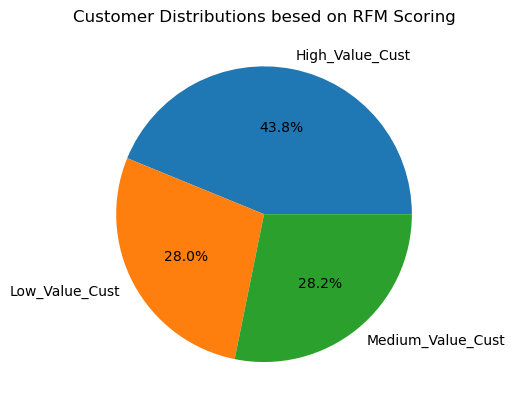

In [166]:
plt.title('Customer Distributions besed on RFM Scoring')
plt.pie(rfm_segments['user_counts'],labels = rfm_segments['RFM_Segments'],autopct = '%1.1f%%')
plt.show()

In [167]:
(rfm_analysis[rfm_analysis['RFM_Segments'] == 'High_Value_Cust'].agg({'Recency':'sum','Monetary':'sum',
                                                                  'Frequency':'sum'}))*100.00/ rfm_analysis.agg({'Recency':'sum',
                                                                                                         'Monetary':'sum','Frequency':'sum'})

Recency      16.624998
Monetary     52.652488
Frequency    44.824065
dtype: float64

In [168]:
(rfm_analysis[rfm_analysis['RFM_Segments'] == 'Medium_Value_Cust'].agg({'Recency':'sum','Monetary':'sum',
                                                                  'Frequency':'sum'}))*100.00/ rfm_analysis.agg({'Recency':'sum',
                                                                                                         'Monetary':'sum','Frequency':'sum'})

Recency      27.436942
Monetary     24.816498
Frequency    27.710210
dtype: float64

In [169]:
(rfm_analysis[rfm_analysis['RFM_Segments'] == 'Low_Value_Cust'].agg({'Recency':'sum','Monetary':'sum',
                                                                  'Frequency':'sum'}))*100.00/ rfm_analysis.agg({'Recency':'sum',
                                                                                                         'Monetary':'sum','Frequency':'sum'})

Recency      55.938060
Monetary     22.531014
Frequency    27.465726
dtype: float64

In [170]:
### The customer are being distributed into high,medium,low cust 
### The most customer are of High which is very good for business 
### In deep drive of these analysis the Low value customer are inavtive and low_value cust and in case of medium customer the 
### customer are active but they also low_value cust as in case of monetary and frequency are quite same not having much changes 
### so, the medium cust we can call them active_low_value_cust 
### so, the low value cust we can call them inactive_low_value_cust 

### the propotion of both low_value + medium value cust contributes around = more than 60% of total which only depicts the business need to take 
### step so that the monetary and frequency will get increase 

### the medium value cust contributes around 28.2% which means customer are active and engaging but not scaling up with the volume of orders 
### we can target them and try to increase them

### our main challenge is value expansion not the customer aquistions 

In [171]:
website_sessions['year'] = website_sessions['created_at'].dt.year
website_sessions['month'] = website_sessions['created_at'].dt.month

In [172]:
website_summary = website_sessions.groupby(['month','device_type'])['user_id'].count().reset_index(name = 'user_counts')

In [173]:
website_summary_pivot = website_summary.pivot(columns = 'device_type',index ='month',values = 'user_counts').reset_index()

In [174]:
desktop_users_prct = website_summary_pivot['desktop'].sum()/ (website_summary_pivot['desktop'] +website_summary_pivot['mobile']).sum()

In [175]:
mobile_users_prct = website_summary_pivot['mobile'].sum()/ (website_summary_pivot['desktop'] +website_summary_pivot['mobile']).sum()

In [176]:
wb = (website_sessions.groupby('device_type')['user_id'].nunique()*100.0
/website_sessions['user_id'].nunique()).reset_index(name = 'user_usage_prct')

In [177]:
wb

,device_type,user_usage_prct
0,desktop,73.184587
1,mobile,33.941895


In [178]:
desktop_user_prct = wb[wb['device_type'] == 'desktop']
mobile_user_prct = wb[wb['device_type'] == 'mobile']

# Users Distributions based on Device_Type

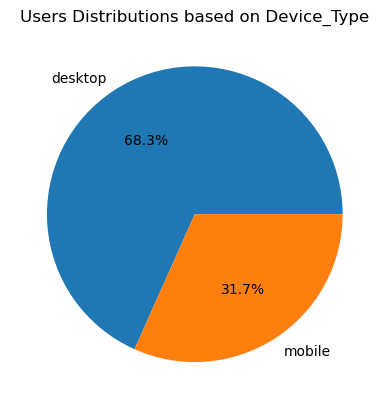

In [179]:
plt.pie(wb['user_usage_prct'],labels = wb['device_type'],autopct = '%1.1f%%')
plt.title('Users Distributions based on Device_Type')
plt.show()

In [180]:
print(mobile_users_prct)
print(desktop_users_prct)

0.3084223815797543
0.6915776184202457


In [181]:
website_summary_pivot

device_type,month,desktop,mobile
0,1,31479,15084
1,2,31609,15622
2,3,26107,12788
3,4,19826,9232
4,5,20865,9381
5,6,21049,8954
6,7,22611,9579
7,8,23626,10241
8,9,24596,11043
9,10,28271,12211


# Users_Traffic By Device Type

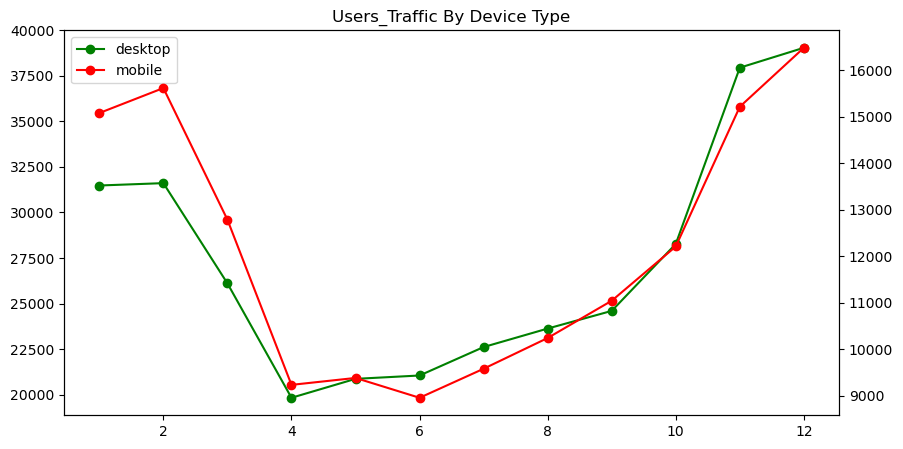

In [182]:
fig,axes = plt.subplots(figsize =(10,5))

line1, = axes.plot(website_summary_pivot['month'],website_summary_pivot['desktop'],color = 'green' , marker ='o',label = 'desktop')
axes.set_title('Users_Traffic By Device Type')


axes_1 = axes.twinx()
line2, = axes_1.plot(website_summary_pivot['month'],website_summary_pivot['mobile'],color = 'red',marker = 'o',label = 'mobile')

axes.legend(handles = [line1,line2],loc ='upper left')
plt.show()

In [183]:
website_sessino_orders_device = pd.merge(orders,website_sessions,on= 'website_session_id',how = 'left',suffixes= ('_orders','_website_sessions'))

In [184]:
website_sessino_orders_device.groupby('device_type')['order_id'].count()

device_type
desktop    27805
mobile      4508
Name: order_id, dtype: int64

# Website_avg_price

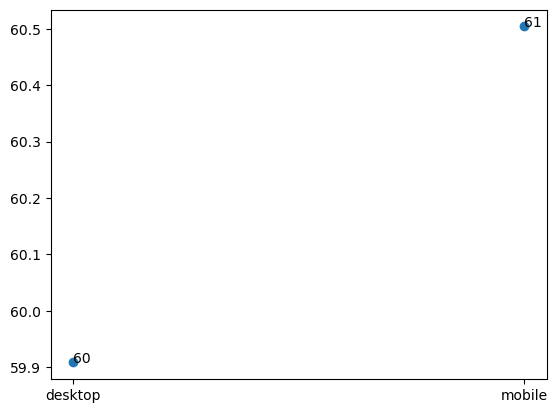

In [185]:
website_avg_price = website_sessino_orders_device.groupby('device_type')['price_usd'].mean().reset_index(name = 'avg_price_usd')

plt.scatter(website_avg_price['device_type'],website_avg_price['avg_price_usd'])

for i ,row in website_avg_price.iterrows():
    plt.text(row['device_type'],row['avg_price_usd'],str(round(row['avg_price_usd'])))

In [186]:
website_avg_price

,device_type,avg_price_usd
0,desktop,59.908572
1,mobile,60.503973


In [187]:

website_sessino_orders_device.groupby('device_type')['order_id'].count()/website_sessino_orders_device['order_id'].count()

device_type
desktop    0.86049
mobile     0.13951
Name: order_id, dtype: float64

In [188]:
website_session_revenue_device = ((website_sessino_orders_device.groupby('device_type')['price_usd'].sum())*100.00/website_sessino_orders_device['price_usd'].sum()).reset_index(name = 'revenue')

In [189]:
website_session_revenue_device

,device_type,revenue
0,desktop,85.929815
1,mobile,14.070185


# Revenue Distribution by Device Type

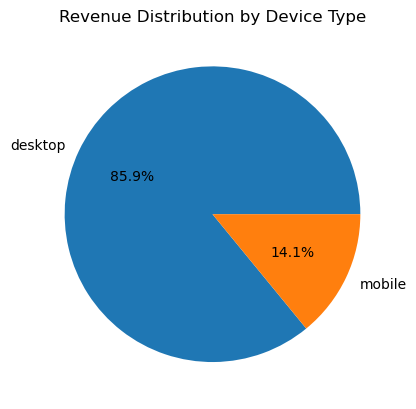

In [190]:
plt.pie(website_session_revenue_device['revenue'],labels = website_session_revenue_device['device_type'],autopct = '%1.1f%%')
plt.title('Revenue Distribution by Device Type')
plt.show()

In [191]:
#### The sessions are being largely dominated by Desktop users compared to mobile users 
#### The orders from desktop is high as compare to mobile users 
#### 85% of revenue is contributed by desktop alone and remaning with mobile 
#### Avg order value in mobile is slighly high then desktop
####This indicates that mobile users are equally valuable per transaction, 
####and the lower revenue contribution from mobile is driven by lower conversion/usage rather than lower spending behavior.

In [192]:
orders_products = pd.merge(order_items,products,on = 'product_id',how = 'left',suffixes= ('_orders','_products'))

In [193]:

products_summary = orders_products.groupby('product_name').agg(Order_counts = ('order_id','count'),launch_date = ('created_at_products','min'),
                                            last_order_date = ('created_at_orders','max'),Total_revenue = ('price_usd','sum'),
                                           ).reset_index()

In [194]:
products_summary['products_age'] = (products_summary['last_order_date'] - products_summary['launch_date']).dt.days

In [195]:
products_summary

,product_name,Order_counts,launch_date,last_order_date,Total_revenue,products_age
0,The Birthday Sugar Panda,4985,2013-12-12 09:00:00,2015-03-19 01:51:39,229260.15,461
1,The Forever Love Bear,5796,2013-01-06 13:00:00,2015-03-19 05:27:28,347702.04,801
2,The Hudson River Mini bear,5018,2014-02-05 10:00:00,2015-03-19 05:35:57,150489.82,406
3,The Original Mr. Fuzzy,24226,2012-03-19 08:00:00,2015-03-19 05:38:31,1211057.74,1094


In [196]:
products_launch =  products_summary
products_launch['launch_datee'] = pd.to_datetime(products_launch['launch_date'],format = '%Y-%m').dt.normalize()
products_launch

,product_name,Order_counts,launch_date,last_order_date,Total_revenue,products_age,launch_datee
0,The Birthday Sugar Panda,4985,2013-12-12 09:00:00,2015-03-19 01:51:39,229260.15,461,2013-12-12
1,The Forever Love Bear,5796,2013-01-06 13:00:00,2015-03-19 05:27:28,347702.04,801,2013-01-06
2,The Hudson River Mini bear,5018,2014-02-05 10:00:00,2015-03-19 05:35:57,150489.82,406,2014-02-05
3,The Original Mr. Fuzzy,24226,2012-03-19 08:00:00,2015-03-19 05:38:31,1211057.74,1094,2012-03-19


# Products Launch TimeLine

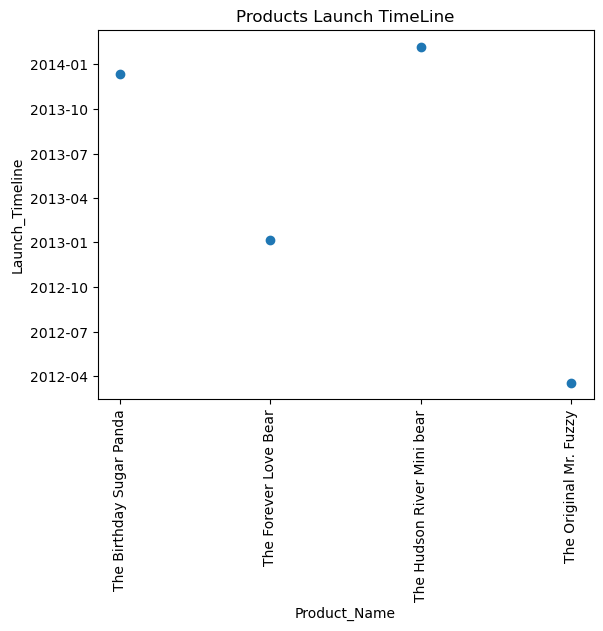

In [197]:
plt.scatter(products_launch['product_name'] , products_launch['launch_datee'])
plt.xticks(products_launch['product_name'] ,rotation = 90)
plt.title('Products Launch TimeLine')
plt.xlabel('Product_Name')
plt.ylabel('Launch_Timeline')
plt.show()

In [198]:
products_orders = pd.merge(order_items,products,on = 'product_id',how = 'left',suffixes=('_order_items','_products'))
products_orders = products_orders.groupby(['year','month','product_name']).agg(Items_Sold = ('order_item_id','count'),Revenue = ('price_usd','sum')).reset_index()
products_orders.to_csv('products_orders_summary.csv',index = False)

In [199]:
##### which products is launched when the products the orignal mr fuzzy launched first and last product which is 
#### launched is The Hudson River Mini bear

In [200]:
products_summary['products_order_day'] = products_summary['Order_counts']/products_summary['products_age']

In [201]:
products_summary['products_revenue_day']  = products_summary['Total_revenue']/products_summary['products_age']

In [202]:
products_summary = products_summary.sort_values(by= 'launch_date')

In [203]:
products_summary['relative_growth_%'] = ((products_summary['products_revenue_day'])*100.00/products_summary['products_revenue_day'].max())

In [204]:
products_summary

,product_name,Order_counts,launch_date,last_order_date,Total_revenue,products_age,launch_datee,products_order_day,products_revenue_day,relative_growth_%
3,The Original Mr. Fuzzy,24226,2012-03-19 08:00:00,2015-03-19 05:38:31,1211057.74,1094,2012-03-19,22.144424,1106.999762,100.000000
1,The Forever Love Bear,5796,2013-01-06 13:00:00,2015-03-19 05:27:28,347702.04,801,2013-01-06,7.235955,434.084944,39.212740
0,The Birthday Sugar Panda,4985,2013-12-12 09:00:00,2015-03-19 01:51:39,229260.15,461,2013-12-12,10.813449,497.310521,44.924176
2,The Hudson River Mini bear,5018,2014-02-05 10:00:00,2015-03-19 05:35:57,150489.82,406,2014-02-05,12.359606,370.664581,33.483709


# Product Productivity Comparison

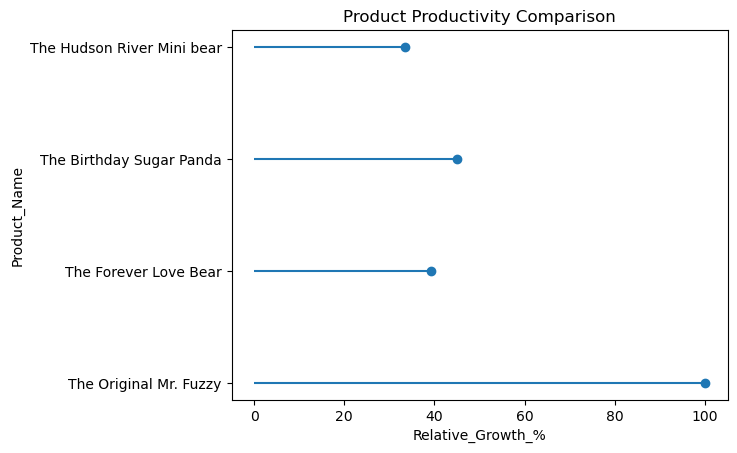

In [205]:
plt.hlines(products_summary['product_name'],xmin = 0,xmax = products_summary['relative_growth_%'])
plt.plot(products_summary['relative_growth_%'],products_summary['product_name'],"o")
plt.xlabel('Relative_Growth_%')
plt.ylabel('Product_Name')
plt.title('Product Productivity Comparison')
plt.show()

In [206]:
products_summary[['product_name','relative_growth_%']]

,product_name,relative_growth_%
3,The Original Mr. Fuzzy,100.000000
1,The Forever Love Bear,39.212740
0,The Birthday Sugar Panda,44.924176
2,The Hudson River Mini bear,33.483709


In [207]:
### Products productivity which product is given the most growth across various products 

In [208]:
#### The Product The Original Mr.Fuzzy is capturing the most in orders as well as revenue per day 
#### The Product (The Birthday Sugar Panda) having a moderate growth but still the Mr.Fuzzy is at peak 
#### The Product which have launched recently is not doing well as the product age is similar for product The Birthday Sugar Panda
#### & The Hudson River Mini bear but still the product The Birthday Sugar Panda has contributed around 45% in relative growth 
#### whereas The Hudson River Mini bear only contributes around 33%
#### This The Hudson River Mini bear is the product which is sold the second most likely to be cross sell products rather than the primary

#### Most sales are driven by Mr.Fuzzy which is risky for the business which can create vulnerability for the business if the demand of this 
#### product decrease then it is going to affect the business negatively.

#### Forever love bear 

In [209]:
orders[orders['items_purchased'] == 1].groupby('primary_product_id')['price_usd'].min()

primary_product_id
1    49.99
2    59.99
3    45.99
4    29.99
Name: price_usd, dtype: float64

In [210]:
combo_products = pd.merge(order_items,products,on = 'product_id',suffixes= ('_orders','_products'))

In [211]:
### 1 is the primary item and secondary = 0
combo_products['Puchase_Type'] = combo_products['is_primary_item'].apply(lambda x:'First_Product_Purchased' if x == 1 else 'Second_Product_Purchased')

In [212]:
combo_productss = combo_products.groupby(['product_name','Puchase_Type'])['order_item_id'].count().reset_index(name = 'order_item_counts')

In [213]:
combo_productss

,product_name,Puchase_Type,order_item_counts
0,The Birthday Sugar Panda,First_Product_Purchased,3068
1,The Birthday Sugar Panda,Second_Product_Purchased,1917
2,The Forever Love Bear,First_Product_Purchased,4803
3,The Forever Love Bear,Second_Product_Purchased,993
4,The Hudson River Mini bear,First_Product_Purchased,581
5,The Hudson River Mini bear,Second_Product_Purchased,4437
6,The Original Mr. Fuzzy,First_Product_Purchased,23861
7,The Original Mr. Fuzzy,Second_Product_Purchased,365


In [214]:

combo_products_pivot = combo_productss.pivot(columns = 'product_name',index = 'Puchase_Type',values = 'order_item_counts')
combo_products_pivot

product_name,The Birthday Sugar Panda,The Forever Love Bear,The Hudson River Mini bear,The Original Mr. Fuzzy
Puchase_Type,,,,
First_Product_Purchased,3068,4803,581,23861
Second_Product_Purchased,1917,993,4437,365


In [215]:
combo_products_pivot

product_name,The Birthday Sugar Panda,The Forever Love Bear,The Hudson River Mini bear,The Original Mr. Fuzzy
Puchase_Type,,,,
First_Product_Purchased,3068,4803,581,23861
Second_Product_Purchased,1917,993,4437,365


# First vs Second Purchase by Product

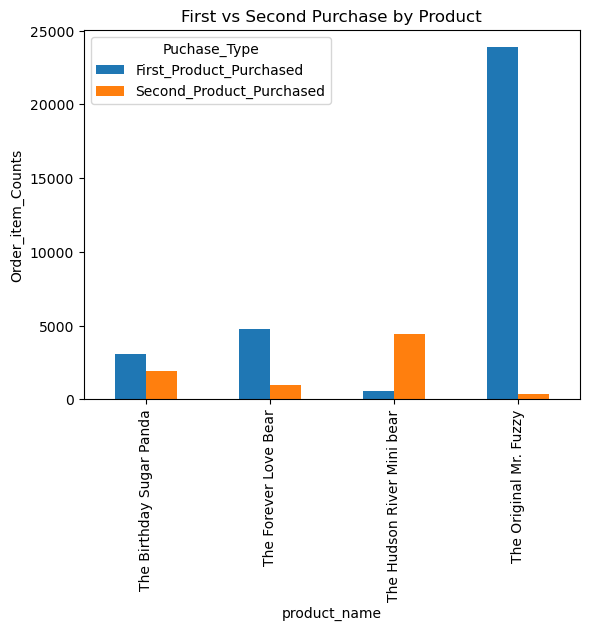

In [216]:
combo_products_pivot.T.plot(kind = 'bar')
plt.title('First vs Second Purchase by Product')
plt.ylabel('Order_item_Counts')
plt.show()

In [217]:
#### cross_sell = which product most likely to second purchase and which one is first purchased 
#### This will show which products is being sold as cross sell and which one is sold as a single product
#### The product orignal mr.fuzzy has been contributed most in terms of first purchase 
### The product which have last launched (the hudson river mini bear) most favourable to be a cross product 


#### The business has a high chances to upsell the product (the hudson river mini bear) as it is most likely to be purchased as secondary 
### products

In [218]:
#### what can be the reason behind customer gone for second product is it due to some drivers????
combo_products.groupby('Puchase_Type')['price_usd'].describe()

### here first product purchased having standard deviation is very less as most of the purchases are of product orignal fuzzy 
### for second product purchased there is so much deviation in prices which is due to products mixed range 

,count,mean,std,min,25%,50%,75%,max
Puchase_Type,,,,,,,,
First_Product_Purchased,32313.0,50.737006,4.797705,29.99,49.99,49.99,49.99,59.99
Second_Product_Purchased,7712.0,38.776566,11.011934,29.99,29.99,29.99,45.99,59.99


In [219]:
combo_products[['price_usd','Puchase_Type']].to_csv('combo_products_price_variation.csv',index = False)

#  Purchase type variation based on price_usd

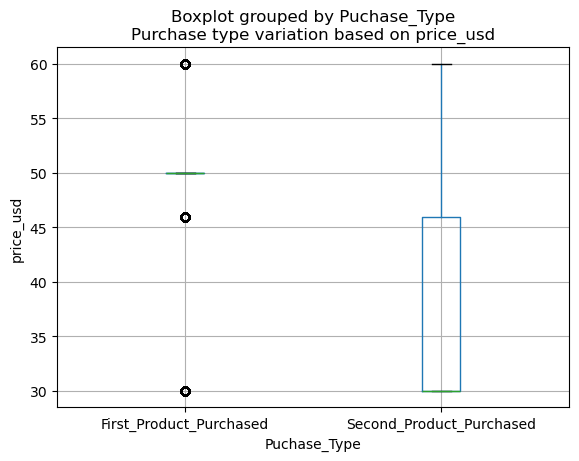

In [220]:
combo_products.boxplot(column = 'price_usd',by = 'Puchase_Type')
plt.title('Purchase type variation based on price_usd')
plt.ylabel('price_usd')
plt.show()
### The boxplot shows that first-purchase products have a concentrated price around $50, indicating a dominant
### primary product tier. In contrast, second-purchase products fall within a lower price range of 
###approximately $30–46. This confirms that customers tend to add lower-priced items as secondary purchases.
###The Hudson River Mini Bear, being among the lowest-priced products, naturally fits this add-on behavior and is 
### therefore more frequently purchased as a cross-sell item.

In [221]:
##### product wise distribution on the basis of profit (monthly wise)

order_products = pd.merge(order_items,products,left_on = 'product_id',right_on = 'product_id',suffixes= ('_orders','_products'))
order_products

,order_item_id,created_at_orders,order_id,product_id,is_primary_item,price_usd,cogs_usd,year,month,created_at_products,product_name
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49,2012,3,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49,2012,3,2012-03-19 08:00:00,The Original Mr. Fuzzy
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49,2012,3,2012-03-19 08:00:00,The Original Mr. Fuzzy
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49,2012,3,2012-03-19 08:00:00,The Original Mr. Fuzzy
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49,2012,3,2012-03-19 08:00:00,The Original Mr. Fuzzy
...,...,...,...,...,...,...,...,...,...,...,...
40020,40015,2015-03-19 00:37:21,32304,4,0,29.99,9.49,2015,3,2014-02-05 10:00:00,The Hudson River Mini bear
40021,40017,2015-03-19 01:42:17,32306,4,1,29.99,9.49,2015,3,2014-02-05 10:00:00,The Hudson River Mini bear
40022,40021,2015-03-19 04:10:43,32310,4,1,29.99,9.49,2015,3,2014-02-05 10:00:00,The Hudson River Mini bear
40023,40023,2015-03-19 05:27:28,32311,4,0,29.99,9.49,2015,3,2014-02-05 10:00:00,The Hudson River Mini bear


In [222]:
orders_products = pd.merge(order_products,order_item_refunds,on = 'order_item_id',how = 'left',suffixes=('_order_products','_order_item_refunds'))
orders_products['refund_revenue'] = (orders_products['price_usd'] - orders_products['refund_amount_usd'].fillna(0).apply(lambda x: 0 if x == 0 else x))
orders_products['refund_cost'] = (orders_products['cogs_usd'] - np.where(orders_products['order_id_order_item_refunds'].isna(),0,orders_products['cogs_usd']))

In [223]:
orders_products['Profit'] = orders_products['refund_revenue'] - orders_products['refund_cost'] 

In [224]:
orders_products.groupby(['month_order_products','product_name'])['Profit'].sum().reset_index()

,month_order_products,product_name,Profit
0,1,The Birthday Sugar Panda,19120.5
1,1,The Forever Love Bear,22837.5
2,1,The Hudson River Mini bear,12361.5
3,1,The Original Mr. Fuzzy,72071.5
4,2,The Birthday Sugar Panda,18333.0
5,2,The Forever Love Bear,42675.0
6,2,The Hudson River Mini bear,15088.0
7,2,The Original Mr. Fuzzy,59383.5
8,3,The Birthday Sugar Panda,14836.5
9,3,The Forever Love Bear,17587.5


In [225]:
### cross sell  #######
orderss_prodcts = order_products.merge(order_products,on = 'order_id')
cross_sell = orderss_prodcts[orderss_prodcts['product_name_x'] < orderss_prodcts['product_name_y']]
cross_sells = cross_sell.groupby(['product_name_x','product_name_y']).agg(Total_orders = ('order_id','count'),Total_Revenue = ('price_usd_x','sum')).reset_index()
cross_sells['combo_products'] = cross_sells['product_name_x'] + '  +  ' + cross_sells['product_name_y']
cross_sells.sort_values(by = 'Total_orders',ascending = False)[['combo_products','Total_orders','Total_Revenue']].to_csv('products_combo.csv',index = False)

In [226]:
order_items_order = pd.merge(order_items,orders , on = 'order_id',how = 'left',suffixes=('_order_items','_orders'))
order_items_order = pd.merge(order_items_order,products,left_on = 'product_id',right_on = 'product_id',suffixes= ('_orders','_products'))

In [227]:

order_items_order['orders_type'] = order_items_order['is_primary_item'].apply(lambda x:'First_Purchase_Products' if x == 1 else 'Secondary_Purchase_Product')

In [228]:
order_items_order = order_items_order.sort_values(by = 'created_at_orders')

In [229]:
order_itemss = order_items_order.groupby(['user_id','orders_type','product_name'])['price_usd_order_items'].sum().reset_index(name = 'revenue')

In [230]:
first_purchase_product = order_itemss[order_itemss['orders_type'] == 'First_Purchase_Products']
second_purchase_product = order_itemss[order_itemss['orders_type'] == 'Secondary_Purchase_Product']
first_second = pd.merge(first_purchase_product,second_purchase_product,on = 'user_id',how = 'left',suffixes= ('_first_purchase','_second_purchase')).fillna(0)

In [231]:
first_second['sell_type'] = np.where(first_second['revenue_first_purchase']<first_second['revenue_second_purchase'] ,'Up_sell' , 'No_upsell')

In [232]:
first_second.groupby(['sell_type'])['user_id'].nunique()

sell_type
No_upsell    30442
Up_sell       1294
Name: user_id, dtype: int64

In [233]:
order_itemss = order_items_order.groupby(['user_id','orders_type'])['price_usd_order_items'].sum().reset_index(name = 'revenue')

In [234]:
order_items_pivot = order_itemss.pivot_table(index = 'user_id',columns = 'orders_type',values = 'revenue')

In [235]:
order_items_pivot['upsell_or_not']  = np.where(order_items_pivot['First_Purchase_Products']<order_items_pivot['Secondary_Purchase_Product'],'up_sell','no_upsell')

In [236]:
order_items_pivot = order_items_pivot.reset_index()

In [237]:
order_items_pivot_products = pd.merge(order_items_pivot,order_items_order,on = 'user_id',how = 'left')

In [238]:
upsell_rate =order_items_pivot_products.groupby(['upsell_or_not','product_name'])['user_id'].count().unstack(fill_value = 0)

In [239]:
upsell_rate.loc['upsell_rate_%'] = upsell_rate.loc['up_sell'] / (upsell_rate.loc['no_upsell'] + upsell_rate.loc['up_sell'])

In [240]:
upsell_rate

product_name,The Birthday Sugar Panda,The Forever Love Bear,The Hudson River Mini bear,The Original Mr. Fuzzy
upsell_or_not,,,,
no_upsell,4592.000000,4846.000000,4974.000000,23117.000000
up_sell,393.000000,950.000000,44.000000,1109.000000
upsell_rate_%,0.078837,0.163906,0.008768,0.045777


In [241]:
upsell_rate_dist = upsell_rate.loc[['no_upsell','up_sell']]

# Distributions of Products Based on Upsell_Rates

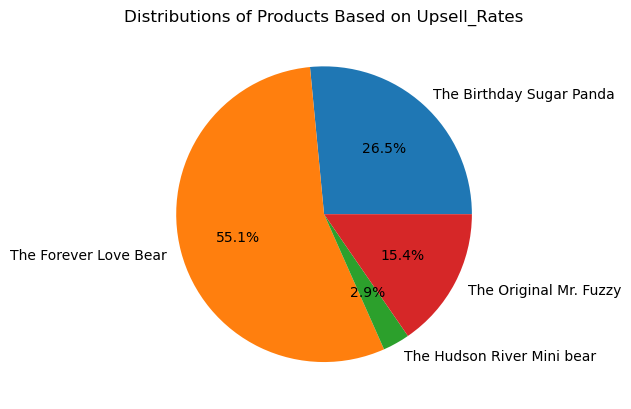

In [242]:
upsell_ratess = upsell_rate.loc['upsell_rate_%']
upsell_ratess = upsell_ratess.reset_index(name = 'Upsell_Rates')
plt.pie(upsell_ratess['Upsell_Rates'],labels = upsell_ratess['product_name'],autopct = '%1.1f%%',textprops={'rotation': 0})
plt.title('Distributions of Products Based on Upsell_Rates')
plt.show()

In [243]:
### The upsell rates of product the forever love bear is the most 

# Upsell vs No-Upsell Users by First Product

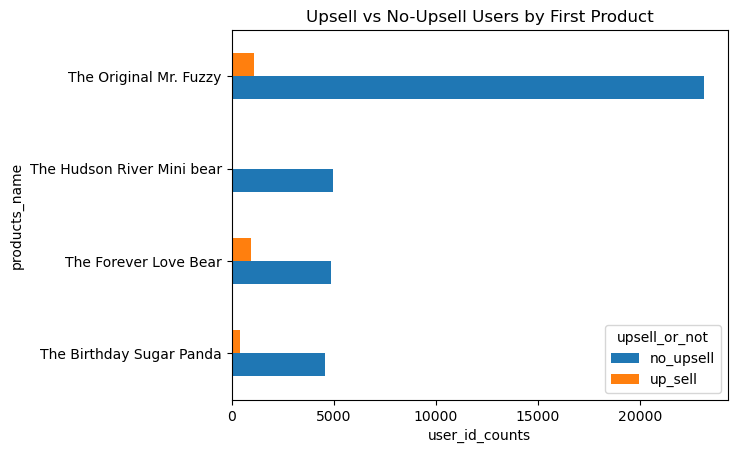

In [244]:
upsell_rate_dist.T.plot(kind = 'barh')
plt.title('Upsell vs No-Upsell Users by First Product')
plt.xlabel('user_id_counts')
plt.ylabel('products_name')
plt.show()

In [245]:
order_items_pivot = order_items_pivot.reset_index().groupby('upsell_or_not')['user_id'].count().reset_index(name = 'user_counts')
order_items_pivot

,upsell_or_not,user_counts
0,no_upsell,30450
1,up_sell,1246


# Distribution of Users: Upsell vs No Upsell

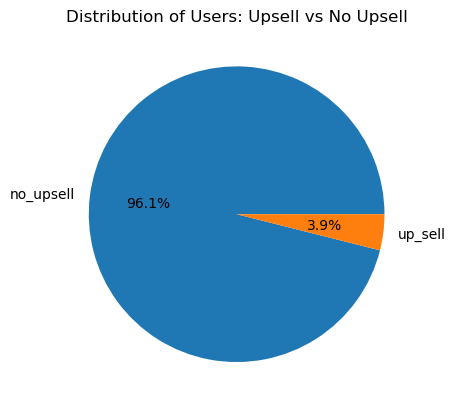

In [246]:
plt.pie(order_items_pivot['user_counts'],labels = order_items_pivot['upsell_or_not'],autopct = '%1.1f%%')
plt.title('Distribution of Users: Upsell vs No Upsell')
plt.show()

In [247]:
### Python analysis measures upsell at the customer level — whether the customer
### spends more in the second purchase phase compared to the first purchase phase overall.

In [248]:
### Conversion Funnel Analysis

In [249]:
website_orders = pd.merge(website_sessions,orders,on = 'website_session_id',how = 'left',suffixes=('_website','orders'))


In [250]:
website_orders_pageview = pd.merge(website_orders,website_pageviews,on = 'website_session_id',how='left')

In [251]:
no_of_order_per_page = website_orders_pageview.groupby('pageview_url')['order_id'].apply(lambda x: x.notna().sum())
no_of_sessions_per_page = website_orders_pageview.groupby('pageview_url')['website_session_id'].nunique()
conversion_rate = no_of_order_per_page*100.00/no_of_sessions_per_page

In [252]:
conversion_rate = conversion_rate.reset_index(name = 'conversion_rate')

In [253]:
#### Entry Page Popularity Distribution
website_orders_pageview.groupby('pageview_url')['user_id_website'].count().sort_values(ascending = False)

pageview_url
/products                      261231
/the-original-mr-fuzzy         162525
/home                          137576
/lander-2                      131170
/cart                           94953
/lander-3                       79000
/lander-5                       68166
/shipping                       64484
/billing-2                      48441
/lander-1                       47574
/thank-you-for-your-order       32313
/the-forever-love-bear          26033
/the-birthday-sugar-panda       19046
/lander-4                        9385
/billing                         3617
/the-hudson-river-mini-bear      2610
Name: user_id_website, dtype: int64

In [254]:
website_orders_pageview = website_orders_pageview.sort_values(['website_session_id','created_at_website'])
website_orders_pageview['page_sequence'] = website_orders_pageview.groupby('website_session_id').cumcount()+1
website_pageview_ss = website_orders_pageview.groupby(['page_sequence','pageview_url'])['user_id_website'].count().reset_index(name = 'user_traffic')

In [255]:
website_pageview_ss['previous_user_traffic'] = website_pageview_ss['user_traffic'].shift(1)

In [256]:
website_pageview_ss['user_traffic_change'] = (website_pageview_ss['user_traffic']-website_pageview_ss['previous_user_traffic'])*100.00/website_pageview_ss['previous_user_traffic']

In [257]:
website_pageview_ss

,page_sequence,pageview_url,user_traffic,previous_user_traffic,user_traffic_change
0,1,/home,137576,NaN,NaN
1,1,/lander-1,47574,137576.0,-65.419841
2,1,/lander-2,131170,47574.0,175.717829
3,1,/lander-3,79000,131170.0,-39.772814
4,1,/lander-4,9385,79000.0,-88.120253
5,1,/lander-5,68166,9385.0,626.329249
6,2,/products,261231,68166.0,283.227709
7,3,/the-birthday-sugar-panda,19046,261231.0,-92.709135
8,3,/the-forever-love-bear,26033,19046.0,36.684868
9,3,/the-hudson-river-mini-bear,2610,26033.0,-89.974263


In [258]:
website_pageview_ss['Pages_Classified'] = np.where(website_pageview_ss['pageview_url'].isin(['/home','/lander-1','/lander-2','/lander-3','/lander-4','/lander-5']),'Landing_Page',
         np.where(website_pageview_ss['pageview_url'].isin(['/products','/the-birthday-sugar-panda','/the-forever-love-bear','/the-hudson-river-mini-bear','/the-original-mr-fuzzy']),'Product_Page',
                  np.where(website_pageview_ss['pageview_url']=='/cart' , 'Cart_Page',np.where(website_pageview_ss['pageview_url']=='/shipping','Shipping_Page',
                                                                                               np.where(website_pageview_ss['pageview_url'].isin(['/billing','/billing-2']),'Billing_Page',
                                                                                              np.where(website_pageview_ss['pageview_url']=='/thank-you-for-your-order','Thankyou_Page','Other_Page'))))))

In [259]:
funnel_traffic = website_pageview_ss.groupby('Pages_Classified')['user_traffic'].sum()
funnel_order = ['Landing_Page','Product_Page','Cart_Page','Shipping_Page','Billing_Page','Thankyou_Page']
funnel_traffic = funnel_traffic.reindex(funnel_order)
funnel_traffic = (funnel_traffic.pct_change()*100).reset_index(name = 'pct_change')
funnel_traffic

,Pages_Classified,pct_change
0,Landing_Page,NaN
1,Product_Page,-0.301562
2,Cart_Page,-79.859156
3,Shipping_Page,-32.088507
4,Billing_Page,-19.269896
5,Thankyou_Page,-37.928849


# Traffic_pct_change by Page_Type

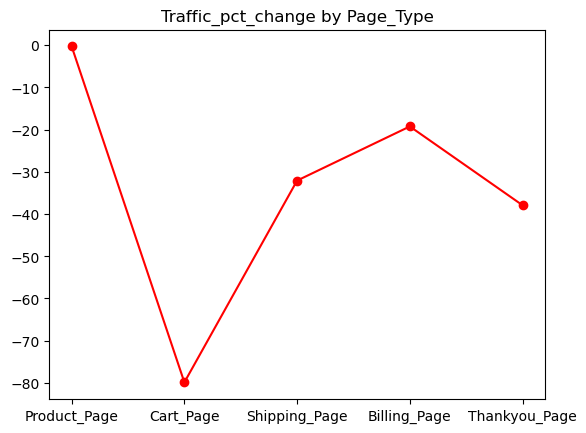

In [260]:
plt.plot(funnel_traffic['Pages_Classified'],funnel_traffic['pct_change'],marker = 'o',color = 'red')
plt.title('Traffic_pct_change by Page_Type')
plt.show()

In [261]:
### “The funnel analysis shows that the largest user drop occurs at the cart page (~80%)
###, indicating significant cart abandonment. Product pages have minimal drop, suggesting
###high engagement with products. Drop-offs during shipping and billing are moderate, while the
###final step to conversion still loses ~38% of remaining users. Optimizing the cart experience could
###substantially increase conversions.”

In [262]:
### page drop analysis 

In [263]:
page_wise_traffic = website_orders_pageview.groupby('page_sequence')['user_id_website'].nunique().reset_index(name = 'users_traffic')

In [264]:
page_wise_traffic['previous_page_traffic'] = page_wise_traffic['users_traffic'].shift(1)

In [265]:

page_wise_traffic['prcnt_traffic_drop'] = (page_wise_traffic['users_traffic']-page_wise_traffic['previous_page_traffic'])*100.00/page_wise_traffic['previous_page_traffic']

In [266]:
page_wise_traffic

,page_sequence,users_traffic,previous_page_traffic,prcnt_traffic_drop
0,1,394318,NaN,NaN
1,2,228771,394318.0,-41.983120
2,3,187941,228771.0,-17.847542
3,4,89895,187941.0,-52.168500
4,5,62099,89895.0,-30.920518
5,6,50511,62099.0,-18.660526
6,7,31696,50511.0,-37.249312


# Page_Wise Traffic Drop

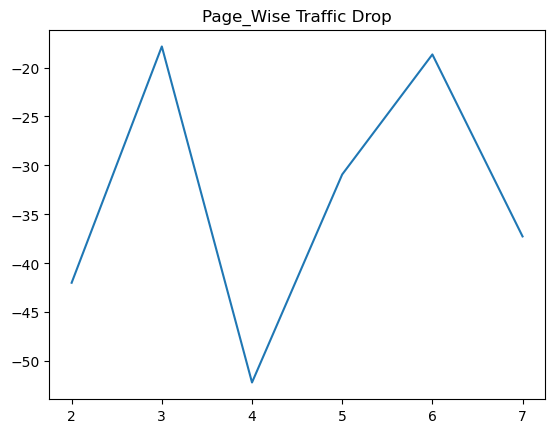

In [267]:
plt.plot(page_wise_traffic['page_sequence'],page_wise_traffic['prcnt_traffic_drop'])
plt.title('Page_Wise Traffic Drop')
plt.show()

In [268]:
np.where(website_orders['order_id'].notna(),1,0).sum()

32313

In [269]:
website_orders['website_session_id'].count()

472871

In [270]:
##### Time To Conversion Analysis 

last_date_user_website_sessions = website_sessions.groupby('user_id')['created_at'].max().reset_index(name = 'last_website_session_date')
last_date_user_order_date = orders.groupby('user_id')['created_at'].max().reset_index(name = 'last_order_date')

In [271]:
time_conversion = pd.merge(last_date_user_website_sessions,last_date_user_order_date,on = 'user_id',how = 'left')

In [272]:
time_conversion['days_btw_session_order'] = (time_conversion['last_website_session_date'] - time_conversion['last_order_date']).dt.days.fillna(99999).astype(int)

In [273]:
time_conversion['Converted_Type'] = time_conversion['days_btw_session_order'].apply(lambda x:'Fast_Converted' if x<10 else 
                                                'Moderate_Converted' if x<=30 else 'Slow_Converted' if (x>30) & (x<99999) else 'Non_Converted')

In [274]:
converted_type_user_counts = time_conversion.groupby('Converted_Type')['user_id'].count().reset_index(name = 'User_counts')

In [275]:
converted_type_user_counts['Converted_user_prct'] = (converted_type_user_counts['User_counts'])*100.00/converted_type_user_counts['User_counts'].sum()

# User Converted Type Distributions

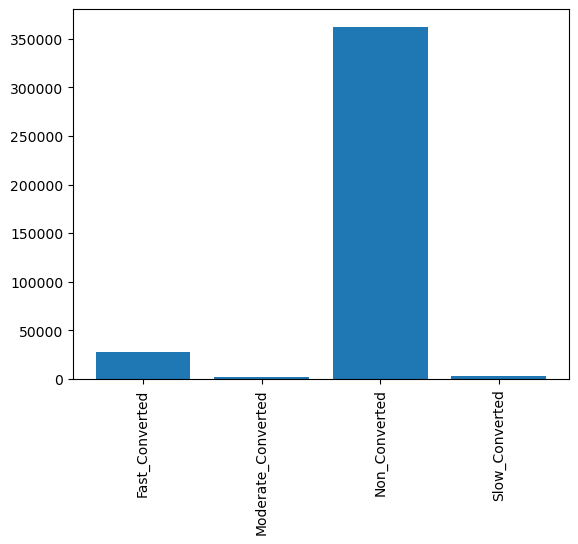

In [276]:
plt.bar(converted_type_user_counts['Converted_Type'] , converted_type_user_counts['User_counts'])
plt.xticks(converted_type_user_counts['Converted_Type'],rotation = 90)
plt.show()

In [277]:
#### There are 91% who haven't been converted also 
#### Fast Converted the user which just converted in less than 10 days 
####Then low converted contributes to 0.6% 
#### at last moderate converters 0.4 

#### Most of user on the website are non_converted 
#### we can give some vouchers to these fast converters 
#### we can say user are actualy hesitating before buying maybe the business not able gain loyalty.
#### Moderate conerters are about 0.4%  

In [278]:
#### Biggest oppurtunity to gain this 91% of Non_Converted user by free first purchase,abandoned cart emails,remarketing .
#### for fast coverters we can do upsell,lowalty rewards 
#### for moderated converters reminders,limited offers

In [279]:
converted_type_user_counts

,Converted_Type,User_counts,Converted_user_prct
0,Fast_Converted,27354,6.937041
1,Moderate_Converted,1887,0.478548
2,Non_Converted,362622,91.961818
3,Slow_Converted,2455,0.622594


# Distribution of User Converted Type

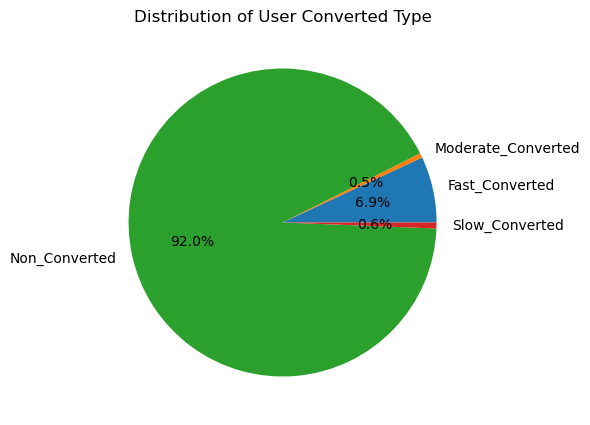

In [280]:
plt.figure(figsize = (11,5))
plt.title('Distribution of User Converted Type')
plt.pie(converted_type_user_counts['Converted_user_prct'],labels = converted_type_user_counts['Converted_Type'],autopct = '%1.1f%%')
plt.show()

In [281]:
conditions = [(website_sessions['utm_source'].isin(['gsearch','bsearch'])),
(website_sessions['utm_source']=='socialbook'),
((website_sessions['utm_source']== 'not applicable') & (website_sessions['http_referer'].str.contains('gsearch',na = False))),
((website_sessions['utm_source']== 'not applicable') & (website_sessions['http_referer'].str.contains('bsearch',na = False))),
((website_sessions['utm_source']== 'not applicable') & (website_sessions['http_referer'].str.contains('socialbook',na = False)))]

choices = ['Paid_Search','Paid_Social','Organic_Search','Organic_Search','Organic Social']

website_sessions['channel_name'] = np.select(conditions,choices,default = 'Direct')

In [282]:
website_sessions[(website_sessions['utm_source']== 'not available') & (website_sessions['http_referer'].str.contains('gsearch',na = False))]

,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer,Time_Slots,year,month,channel_name


In [283]:
website_sessions['utm_source'].unique()

array(['gsearch', 'not applicable', 'bsearch', 'socialbook'], dtype=object)

In [284]:
website_sessions['channel_name'].unique()

array(['Paid_Search', 'Direct', 'Organic_Search', 'Paid_Social'],
      dtype=object)

In [285]:
#### Channel Attributions 

website_sessions['channel_type'] = website_sessions['utm_source'].apply(lambda x: 'Paid' if x in ['gsearch','socialbook','bsearch'] else 'Free')

In [286]:
website_sessions_orders = pd.merge(website_sessions,orders,on = 'website_session_id',how = 'left',suffixes= (['_website_session','_orders']))

In [287]:
website_channel_summary = website_sessions_orders.groupby(['channel_type','channel_name']).agg(website_user_counts = ('user_id_website_session','nunique'),website_session_counts = ('website_session_id','nunique')
                                                                    ,orders_counts= ('order_id' , lambda x :x.notna().sum())).reset_index()

In [288]:
website_channel_summary['conversion_rate'] = (website_channel_summary['orders_counts']*100.00)/website_channel_summary['website_session_counts']

In [289]:
website_channel_summary

,channel_type,channel_name,website_user_counts,website_session_counts,orders_counts,conversion_rate
0,Free,Direct,35367,39917,2856,7.154846
1,Free,Organic_Search,38051,43411,3262,7.514225
2,Paid,Paid_Search,355213,378858,25852,6.823665
3,Paid,Paid_Social,10685,10685,343,3.210108


# Channel Perfomance Overview

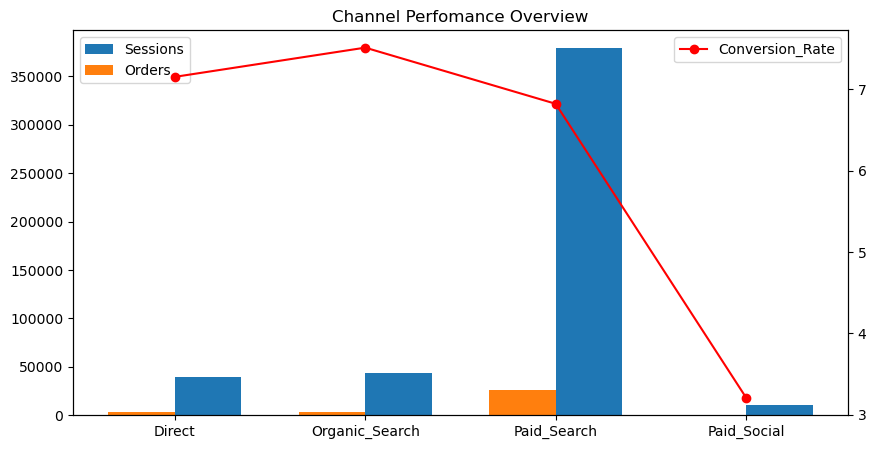

In [290]:
fig,axes = plt.subplots(figsize = (10,5))

x= np.arange(len(website_channel_summary['channel_name']))
width = 0.35

bar1 = axes.bar(x+width / 2 ,website_channel_summary['website_session_counts'],width,label = 'Sessions')
bar2 = axes.bar(x-width / 2 ,website_channel_summary['orders_counts'],width,label = 'Orders')

axes2 = axes.twinx()

axes2.plot(website_channel_summary['channel_name'],website_channel_summary['conversion_rate'],color = 'red',marker = 'o',label = 'Conversion_Rate')

axes.legend(loc = 'upper left')
axes2.legend(loc = 'upper right')
plt.title('Channel Perfomance Overview')
plt.show()

In [291]:
website_channel_summary[['channel_name','channel_type','website_session_counts','orders_counts','conversion_rate']]

,channel_name,channel_type,website_session_counts,orders_counts,conversion_rate
0,Direct,Free,39917,2856,7.154846
1,Organic_Search,Free,43411,3262,7.514225
2,Paid_Search,Paid,378858,25852,6.823665
3,Paid_Social,Paid,10685,343,3.210108


In [292]:
##### The business largely dependedent on paid channel_type about 84.7% and then free channel about 15.3% 
#### but for early business it is fine 
#### But the large dependent on paid channel will result in increase in customer acqustion and also 
#### it is not good for long term sustanibility.
#### Conversion rate of Organic search which is free channel type is high as compare to paid_search 
#### which means business is creating awarness and consideration by paid but with low intent of purchase whereas 
#### Organic search are with high intent to do purchase 
#### this means that customer are get first influenced by paid_channel then get converted by organi search 

In [293]:

website_session_channel = ((website_sessions.groupby('channel_type')['user_id'].nunique())*100.00/website_sessions['user_id'].nunique()).reset_index(name = 'cust_counts')

# Ditribution of Traffic by channel_type

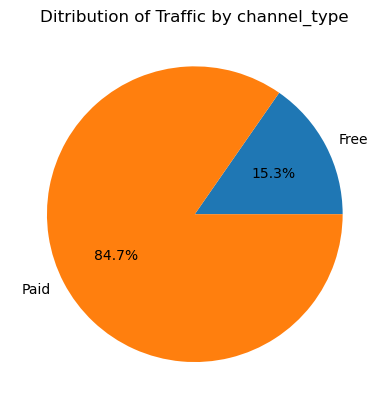

In [294]:

plt.pie(website_session_channel['cust_counts'],labels = website_session_channel['channel_type'],autopct = '%1.1f%%')
plt.title('Ditribution of Traffic by channel_type')
plt.show()

In [295]:
website_session_channel

,channel_type,cust_counts
0,Free,16.774279
1,Paid,92.599628


In [296]:
website_session_yearly = website_sessions.groupby(['year','channel_name'])['website_session_id'].count().reset_index(name = 'website_counts')
website_session_yearly = website_session_yearly.sort_values(['channel_name','year'])
website_session_yearly['previous_year_session_counts'] = website_session_yearly.groupby('channel_name')['website_counts'].shift(1)
website_session_yearly['prct_change_session_counts'] = (website_session_yearly['website_counts']-website_session_yearly['previous_year_session_counts'])*100.00/website_session_yearly['previous_year_session_counts']
website_session_yearly

,year,channel_name,website_counts,previous_year_session_counts,prct_change_session_counts
0,2012,Direct,2780,NaN,NaN
3,2013,Direct,8136,2780.0,192.661871
6,2014,Direct,21877,8136.0,168.891347
10,2015,Direct,7124,21877.0,-67.436120
1,2012,Organic_Search,2973,NaN,NaN
4,2013,Organic_Search,8914,2973.0,199.831820
7,2014,Organic_Search,23732,8914.0,166.232892
11,2015,Organic_Search,7792,23732.0,-67.166695
2,2012,Paid_Search,56717,NaN,NaN
5,2013,Paid_Search,95731,56717.0,68.787136


In [416]:
### Path Analysis
website_sessio = website_sessions.sort_values(['user_id','created_at','website_session_id'])
path_analysis_summ = website_sessio[website_sessio.groupby('user_id')['channel_name'].transform('nunique')>1]

In [417]:
#path_analysis_summ =path_analysis_summ.sort_values(['user_id','created_at','website_session_id'])

In [418]:
path_analysis_summ['row_no'] = path_analysis_summ.groupby('user_id')['created_at'].cumcount()+1

C:\Users\Harshita Sahu\AppData\Local\Temp\ipykernel_3248\3057714868.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  path_analysis_summ['row_no'] = path_analysis_summ.groupby('user_id')['created_at'].cumcount()+1


In [419]:
path_analysis_summ =path_analysis_summ[path_analysis_summ['row_no'].isin([1,2])]

In [420]:
path_pivot = path_analysis_summ.pivot(index = 'user_id',columns = 'row_no' ,values = 'channel_name')

In [421]:
path_pivot = path_pivot.reset_index()

In [422]:
path_pivot

row_no,user_id,1,2
0,27,Paid_Search,Organic_Search
1,36,Paid_Search,Organic_Search
2,46,Paid_Search,Organic_Search
3,57,Paid_Search,Direct
4,59,Paid_Search,Organic_Search
...,...,...,...
38613,391079,Paid_Search,Direct
38614,391087,Direct,Organic_Search
38615,391226,Paid_Search,Direct
38616,391234,Paid_Search,Direct


In [423]:
path_pivot['channel_shift'] = path_pivot[1] +'_to_'+ path_pivot[2]

In [424]:
### Path_Pivot 
path_pivots = path_pivot.groupby('channel_shift')['user_id'].count().reset_index(name = 'channel_counts')
path_pivots

,channel_shift,channel_counts
0,Direct_to_Direct,169
1,Direct_to_Organic_Search,677
2,Direct_to_Paid_Search,662
3,Organic_Search_to_Direct,666
4,Organic_Search_to_Organic_Search,185
5,Organic_Search_to_Paid_Search,710
6,Paid_Search_to_Direct,14791
7,Paid_Search_to_Organic_Search,15515
8,Paid_Search_to_Paid_Search,3548
9,Paid_Social_to_Direct,565


# Path Analysis to Channel_Shift

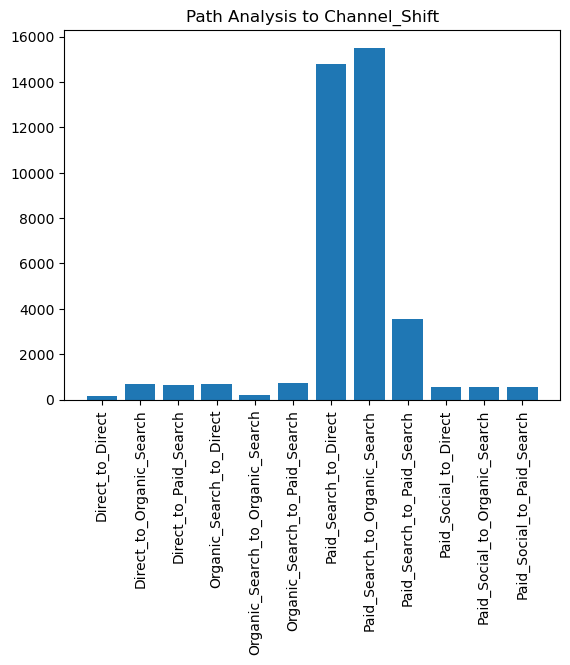

In [408]:
plt.bar(path_pivots['channel_shift'],path_pivots['channel_counts'])
plt.xticks(path_pivots['channel_shift'],rotation = 90)
plt.title('Path Analysis to Channel_Shift')
plt.show()

In [409]:
path_analysis_summ = website_sessions[website_sessions.groupby('user_id')['channel_name'].transform('nunique')>1]
path_analysis_summ['row_no'] = path_analysis_summ.groupby('user_id')['created_at'].cumcount()+1

C:\Users\Harshita Sahu\AppData\Local\Temp\ipykernel_3248\1514146843.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  path_analysis_summ['row_no'] = path_analysis_summ.groupby('user_id')['created_at'].cumcount()+1


In [410]:
path_analysis_summ['row_no'] = path_analysis_summ['row_no'].astype('int')

C:\Users\Harshita Sahu\AppData\Local\Temp\ipykernel_3248\2141163295.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  path_analysis_summ['row_no'] = path_analysis_summ['row_no'].astype('int')


In [411]:
website_sessions['row_no'] = website_sessions.groupby('user_id')['created_at'].cumcount()+1

In [412]:
websites_sessions_orders = pd.merge(orders,website_sessions,on = 'user_id',how = 'left',suffixes=('_orders','_website_session'))

In [413]:

orders_channel = websites_sessions_orders.groupby('channel_name').agg(orders_count = ('order_id','count')).reset_index()

# Orders count By Channel_Name

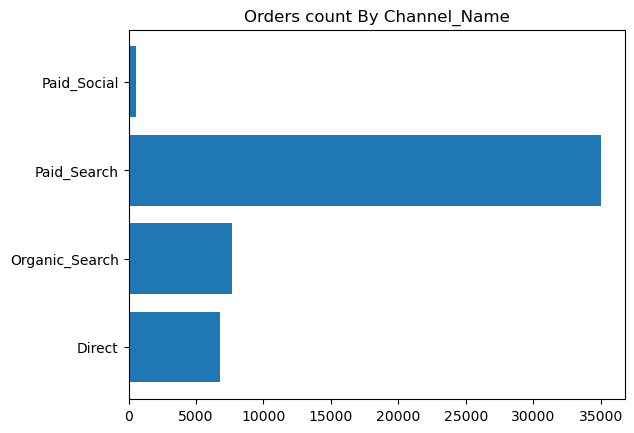

In [414]:
plt.barh(orders_channel['channel_name'],orders_channel['orders_count'])
plt.title('Orders count By Channel_Name')
plt.show()

In [313]:
orders_channel

,channel_name,orders_count
0,Direct,6789
1,Organic_Search,7670
2,Paid_Search,35026
3,Paid_Social,532


In [314]:

websites_sessions_orders.groupby(['channel_name','channel_type']).agg(users_count = ('user_id','nunique')).reset_index()

,channel_name,channel_type,users_count
0,Direct,Free,5168
1,Organic_Search,Free,5711
2,Paid_Search,Paid,29082
3,Paid_Social,Paid,526


In [315]:
wesbite_explore = website_sessions.groupby(['year','month','channel_name'])['website_session_id'].count().reset_index()
wesbite_explore.to_csv('wesbite_explore.csv',index = False)

In [316]:
#### Bounce Rate Analysis 
landing = website_pageviews.groupby('website_session_id').first().reset_index()
landing

,website_session_id,website_pageview_id,created_at,pageview_url
0,1,1,2012-03-19 08:04:16,/home
1,2,2,2012-03-19 08:16:49,/home
2,3,3,2012-03-19 08:26:55,/home
3,4,4,2012-03-19 08:37:33,/home
4,5,5,2012-03-19 09:00:55,/home
...,...,...,...,...
472866,472867,1188111,2015-03-19 07:49:25,/home
472867,472868,1188114,2015-03-19 07:54:36,/lander-3
472868,472869,1188116,2015-03-19 07:55:40,/lander-3
472869,472870,1188118,2015-03-19 07:56:29,/lander-5


In [317]:
counts = website_pageviews.groupby('website_session_id').size().reset_index(name = 'pages')

In [318]:
counts

,website_session_id,pages
0,1,1
1,2,1
2,3,1
3,4,1
4,5,1
...,...,...
472866,472867,2
472867,472868,3
472868,472869,1
472869,472870,3


In [319]:
counts['is_bounce'] = (counts['pages'] == 1).astype('int')
sessions = pd.merge(counts,landing,how = 'left',on ='website_session_id')
page_wise_bounce_rates = sessions.groupby('pageview_url')['is_bounce'].mean().reset_index(name = 'bounce_rates')
page_wise_bounce_rates

,pageview_url,bounce_rates
0,/home,0.416831
1,/lander-1,0.532434
2,/lander-2,0.451696
3,/lander-3,0.502949
4,/lander-4,0.516889
5,/lander-5,0.368674


# Page_view distributions based on bounce rates

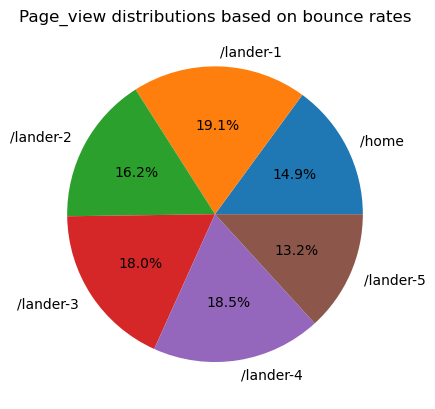

In [320]:
plt.pie(page_wise_bounce_rates['bounce_rates'],labels=page_wise_bounce_rates['pageview_url'],autopct = '%1.1f%%')
plt.title('Page_view distributions based on bounce rates')
plt.show()

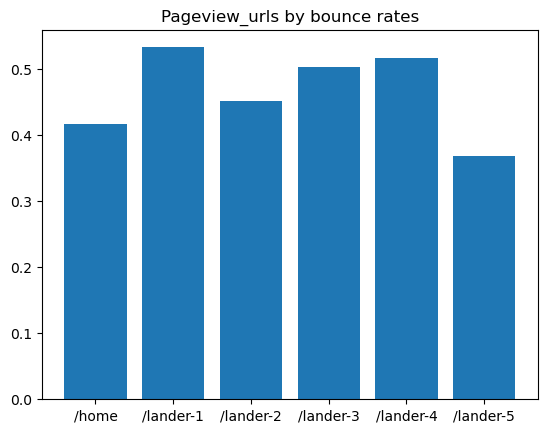

In [321]:
plt.bar(page_wise_bounce_rates['pageview_url'],page_wise_bounce_rates['bounce_rates'])
plt.title('Pageview_urls by bounce rates')
plt.show()

In [322]:
### Here , it is been observed the bounce rate at lander - 1 is highest that means after just veiwing this page 
### people left that means the landing page not effectively managing or matching the customer expectations 
### the bounce rate is least at landing page 5 that means there is a chance for these users that they may continue bowse more 

In [323]:
page_wise_bounce_rates

,pageview_url,bounce_rates
0,/home,0.416831
1,/lander-1,0.532434
2,/lander-2,0.451696
3,/lander-3,0.502949
4,/lander-4,0.516889
5,/lander-5,0.368674


In [324]:
#### Campaign Performance Analysis 
website_orders = pd.merge(website_sessions,orders,on = 'website_session_id',how = 'left',suffixes= ('_website','_orders'))
campian_performance  = ((website_orders.groupby(['channel_name','utm_campaign'])['order_id'].apply(lambda x:x.notna().sum()))*100.00/website_orders.groupby(['channel_name','utm_campaign'])['website_session_id'].count()).reset_index(name = 'conversion_rate')

In [325]:
campian_performance

,channel_name,utm_campaign,conversion_rate
0,Direct,not applicable,7.154846
1,Organic_Search,not applicable,7.514225
2,Paid_Search,brand,7.787988
3,Paid_Search,nonbrand,6.705863
4,Paid_Social,desktop_targeted,5.152057
5,Paid_Social,pilot,1.079490


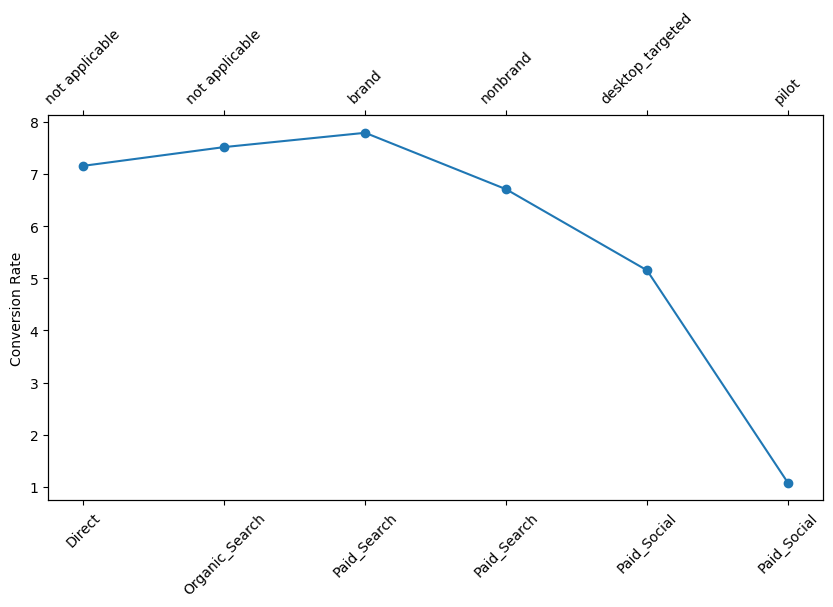

In [326]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(campian_performance))

fig, ax1 = plt.subplots(figsize=(10,5))

# bottom axis (channel)
ax1.plot(x, campian_performance['conversion_rate'], marker='o')
ax1.set_xticks(x)
ax1.set_xticklabels(campian_performance['channel_name'], rotation=45)
ax1.set_ylabel("Conversion Rate")

# top axis (campaign)
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(x)
ax2.set_xticklabels(campian_performance['utm_campaign'], rotation=45)

plt.show()


In [327]:
### Paid search of utm_campaign as brand having conversion rate the highest 
### Orgain_search & Direct free channels having conversion rate around 7%

In [328]:
#### the dependency of business of which channel_type 

website_sessions[website_sessions['channel_type'] == 'Paid']['user_id'].nunique()

365137

In [329]:
#### users coming from channel type paid 
((website_sessions[website_sessions['channel_type'] == 'Paid']['user_id'].nunique())*100.00/website_sessions['user_id'].nunique())

92.5996277116439

In [330]:
#### users coming from channel type free
((website_sessions[website_sessions['channel_type'] == 'Free']['user_id'].nunique())*100.00/website_sessions['user_id'].nunique())

16.774278627909453

In [331]:
#### number of sessions by channel type paid 
((website_sessions[website_sessions['channel_type'] == 'Paid']['website_session_id'].nunique())*100.00/website_sessions['website_session_id'].nunique())

82.37828075733128

In [332]:
#### number of sessions by channel type free 
((website_sessions[website_sessions['channel_type'] == 'Free']['website_session_id'].nunique())*100.00/website_sessions['website_session_id'].nunique())

17.621719242668718

In [333]:
channel_paid_conversion = website_orders[website_orders['channel_type'] == 'Paid']

In [334]:

(channel_paid_conversion[channel_paid_conversion['order_id'].notna()]['order_id'].nunique())*100.00/channel_paid_conversion['website_session_id'].nunique() 

6.724546455718624

In [335]:
channel_free_conversion = website_orders[website_orders['channel_type'] == 'Free']
(channel_free_conversion[channel_free_conversion['order_id'].notna()]['order_id'].nunique())*100.00/channel_free_conversion['website_session_id'].nunique() 

7.342069892473118

In [336]:

channel_type_summary = website_orders.groupby('channel_type').agg(Total_orders = ('order_id',lambda x:x.notna().sum()),
                                           Total_sessions = ('website_session_id','nunique'),
                                           Total_revenue = ('price_usd','sum')).reset_index()

In [337]:
channel_type_summary['Total_orders_pct'] = channel_type_summary['Total_orders']*100.00/channel_type_summary['Total_orders'].sum()
channel_type_summary['Total_sessions_pct'] = channel_type_summary['Total_sessions']*100.00/channel_type_summary['Total_sessions'].sum()
channel_type_summary['Total_revenue_pct'] = channel_type_summary['Total_revenue']*100.00/channel_type_summary['Total_revenue'].sum()

In [338]:
channel_type_summary

,channel_type,Total_orders,Total_sessions,Total_revenue,Total_orders_pct,Total_sessions_pct,Total_revenue_pct
0,Free,6118,83328,371433.03,18.933556,17.621719,19.160751
1,Paid,26195,389543,1567076.72,81.066444,82.378281,80.839249


# Channel Contribution: Orders vs Sessions vs Revenue

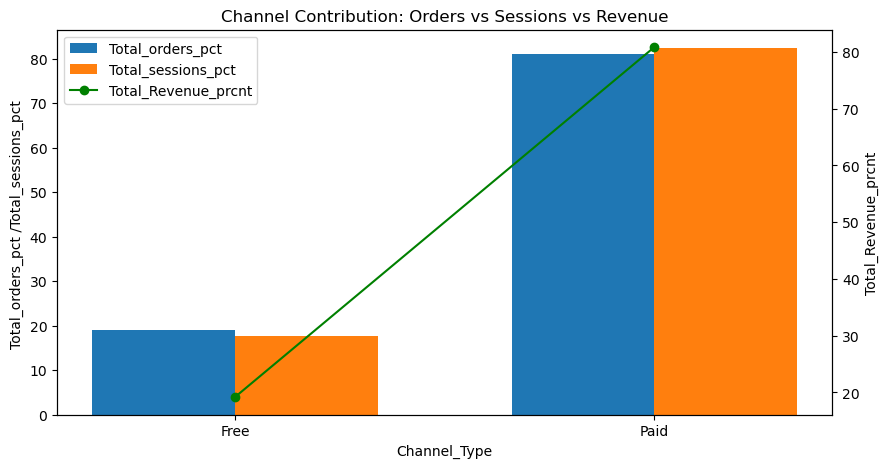

In [339]:
fig,axes = plt.subplots(figsize = (10,5))

x = np.arange(len(channel_type_summary['channel_type']))
width = 0.34

axes.bar(x-width/2,channel_type_summary['Total_orders_pct'],width,label = 'Total_orders_pct')
axes.bar(x+width/2,channel_type_summary['Total_sessions_pct'],width,label = 'Total_sessions_pct')

axes2 = axes.twinx()

axes2.plot(x,channel_type_summary['Total_revenue_pct'],marker = 'o',color = 'green',label = 'Total_Revenue_prcnt')
axes.set_xticks(x)
axes.set_xticklabels(channel_type_summary['channel_type'])

lines1,labels1 = axes.get_legend_handles_labels()
lines2,labels2 = axes2.get_legend_handles_labels()
axes.legend(lines1 +lines2 , labels1 +  labels2)

plt.title('Channel Contribution: Orders vs Sessions vs Revenue')
axes.set_xlabel('Channel_Type')
axes.set_ylabel('Total_orders_pct /Total_sessions_pct ')
axes2.set_ylabel('Total_Revenue_prcnt')
plt.show()

In [340]:
channel_type_summary[['channel_type','Total_orders_pct','Total_sessions_pct','Total_revenue_pct']]

,channel_type,Total_orders_pct,Total_sessions_pct,Total_revenue_pct
0,Free,18.933556,17.621719,19.160751
1,Paid,81.066444,82.378281,80.839249


In [341]:
### the customer can have multiple channels paid or free 
### the business largely dependent on paid channel as the Total_sessions and Total_orders is comparitively larger
### than free channel that's why revenue drive by paid is more 
### in case of conversion rate free channels converts faster than paid one whereas traffic acquistion is largely influenced by
### paid channel

##Paid channels dominate traffic, orders, and revenue
##Free channels generate fewer sessions but higher conversion
##Business relies on Paid for scale, Free for efficiency

In [342]:
website_sessions_device = website_sessions

In [343]:
website_session_device_orders = pd.merge(website_sessions_device,orders , on = 'website_session_id',how = 'left',suffixes= ('_website_session','_orders'))

In [344]:
website_session_device_orders = website_session_device_orders.sort_values('created_at_website_session')

In [345]:
#### where device is more than 1 and distinct devices 
website_session_device_orders = website_session_device_orders[website_session_device_orders.groupby('user_id_website_session')['device_type'].transform('nunique')>1]

In [346]:
website_session_device_orders = website_session_device_orders[~website_session_device_orders.duplicated(['user_id_website_session','device_type'])]
website_session_device_orders['device_count_type'] = website_session_device_orders.groupby('user_id_website_session')['device_type'].cumcount()+1
website_session_device_orders['device_type_usage'] = np.where(website_session_device_orders['device_count_type'] == 1,'First_Device_Type','Second_Device_Type')

In [347]:
website_session_device_orders['converted_into_order'] =np.where(website_session_device_orders['order_id'].notna(),'Converted','Not_Converted')

In [348]:
website_session_device_orders_pivot = website_session_device_orders.pivot(index ='user_id_website_session',columns = 'device_type_usage',values = 'device_type')
website_session_device_orders_pivot['device_shift'] = website_session_device_orders_pivot['First_Device_Type'] + '_to_' + website_session_device_orders_pivot['Second_Device_Type']

In [349]:
device_shift_counts = website_session_device_orders_pivot.groupby('device_shift').size().reset_index(name = 'user_counts')

# User counts based of Device shift

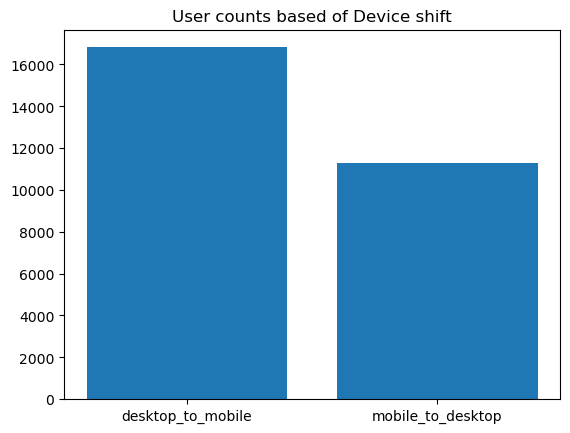

In [350]:
plt.bar(device_shift_counts['device_shift'],device_shift_counts['user_counts'])
plt.title('User counts based of Device shift')
plt.show()

In [351]:
device_shift_counts

,device_shift,user_counts
0,desktop_to_mobile,16827
1,mobile_to_desktop,11274


In [352]:
#### here in case of traffic most customer started off with desktop then shifted to mobile 
#### then some of them started off with mobile then shifted to desktop

In [353]:
conversion_or_not = pd.merge(website_session_device_orders_pivot,website_session_device_orders,on = 'user_id_website_session',how= 'left')

In [354]:
conversion_or_not = conversion_or_not.groupby(['converted_into_order','device_shift'])['user_id_website_session'].count().reset_index(name = 'user_counts')

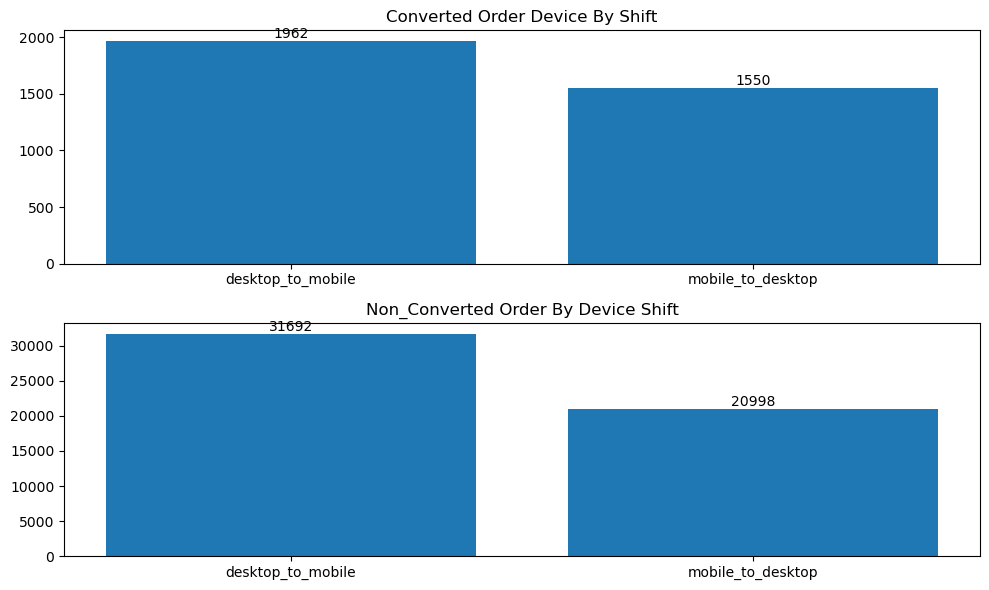

In [355]:
fig,axes = plt.subplots(2,1,figsize = (10,6))

converted_orders = conversion_or_not[conversion_or_not['converted_into_order'] == 'Converted']
axes[0].bar(converted_orders['device_shift'],converted_orders['user_counts'])
axes[0].set_title('Converted Order Device By Shift')

for i,val in enumerate(converted_orders['user_counts']):
    axes[0].text(i,val,str(val),ha = 'center' , va = 'bottom')

non_converted_orders = conversion_or_not[conversion_or_not['converted_into_order'] == 'Not_Converted']
axes[1].bar(non_converted_orders['device_shift'],non_converted_orders['user_counts'])

for i,val in enumerate(non_converted_orders['user_counts']):
    axes[1].text(i,val,str(val),ha = 'center' , va = 'bottom')

axes[1].set_title('Non_Converted Order By Device Shift')

plt.tight_layout()

In [356]:
converted_orders['conversion_rate'] = (converted_orders['user_counts'])*100.00/converted_orders['user_counts'].sum()

C:\Users\Harshita Sahu\AppData\Local\Temp\ipykernel_3248\763811210.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  converted_orders['conversion_rate'] = (converted_orders['user_counts'])*100.00/converted_orders['user_counts'].sum()


In [357]:
### It is very evidient from the above chart that the customer
### who the desktop to mobile have higher contribution to total_conversion by device shift

In [358]:
conversion_ratesss = ((conversion_or_not[conversion_or_not['converted_into_order'] == 'Converted'].groupby('device_shift')['user_counts'].sum())*100.00/conversion_or_not.groupby('device_shift')['user_counts'].sum()).reset_index(name  = 'conversion_rate')

# Total_Conversion Rate by Device_Shift

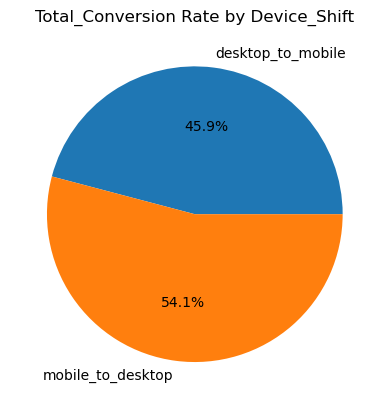

In [359]:
plt.pie(conversion_ratesss['conversion_rate'],labels = conversion_ratesss['device_shift'],autopct = '%1.1f%%')
plt.title('Total_Conversion Rate by Device_Shift')
plt.show()

In [360]:
### there is a high chances of user to get converted whose first device is mobile then shiting to deskstop 
### The business itself having a high traffic for the customer who are using desktop about more than 80% .
### That means the users who are login with mobile have high chances to get converted as compare to desktop 

In [361]:
#### cart abandoment or not / funnel stage / cart journey stage

In [362]:
cart_abandonment = website_pageviews

In [363]:
cart_abandonment['created_at'] = cart_abandonment['created_at'].sort_values()

In [364]:
cart_abandonment['pageviews_row_no'] = cart_abandonment.groupby('website_session_id')['pageview_url'].cumcount()+1

In [365]:
cart_abandonment['pageview_url'].unique()

array(['/home', '/products', '/the-original-mr-fuzzy', '/cart',
       '/shipping', '/billing', '/thank-you-for-your-order', '/lander-1',
       '/billing-2', '/the-forever-love-bear', '/lander-2', '/lander-3',
       '/the-birthday-sugar-panda', '/lander-4', '/lander-5',
       '/the-hudson-river-mini-bear'], dtype=object)

In [366]:
cart_abandonment['last_page_viewed'] = cart_abandonment.groupby('website_session_id')['pageviews_row_no'].max().astype('int')

In [367]:
cart_abandonment = cart_abandonment.drop(columns = 'last_page_viewed')

In [368]:
last_page = cart_abandonment.groupby('website_session_id')['pageviews_row_no'].max().reset_index(name = 'last_page_viewed')

In [369]:
last_page['funnel_stage'] = np.where(last_page['last_page_viewed'] == 4 ,'Cart_Abandonment',np.where (last_page['last_page_viewed'] <4 ,'Not_Yet_Reached_To_Cart','Beyond_Cart_Page'))

In [370]:
funnel_stage = last_page.groupby('funnel_stage')['website_session_id'].nunique().reset_index(name = 'sessions_counts')
funnel_stage

,funnel_stage,sessions_counts
0,Beyond_Cart_Page,64484
1,Cart_Abandonment,30469
2,Not_Yet_Reached_To_Cart,377918


# Last Page Stage

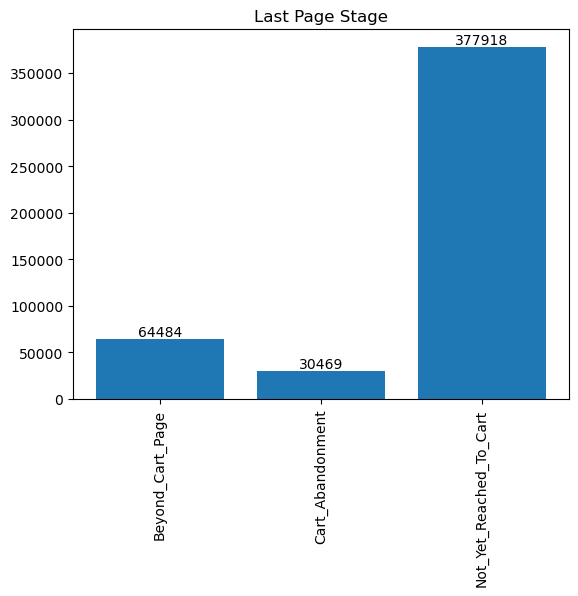

In [371]:
plt.bar(funnel_stage['funnel_stage'],funnel_stage['sessions_counts'])
plt.title('Last Page Stage')
plt.xticks(funnel_stage['funnel_stage'],rotation = 90)

for i,val in enumerate(funnel_stage['sessions_counts']):
    plt.text(i,val+0.05,val,ha ='center',va = 'bottom')
plt.show()

# Funnel Stage Distributions

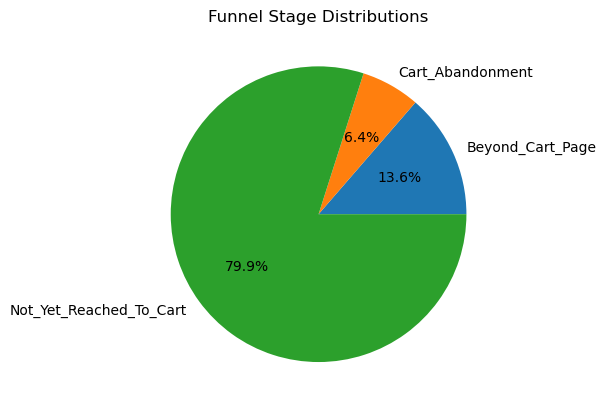

In [372]:
plt.pie(funnel_stage['sessions_counts'],labels = funnel_stage['funnel_stage'],autopct = '%1.1f%%')
plt.title('Funnel Stage Distributions')
plt.show()

In [373]:
### about 79.9% sessions where user haven't reached till the cart .
### about 6.4% of users left at the cart page and about 13.6% goes beyond it .
### this tell where the traffic drop off at what page helps in funnel optimizations .

In [374]:
### is there is any change after launching the product in revenue orders??

products

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


In [375]:

orders_products = pd.merge(orders,products, left_on = 'primary_product_id',right_on = 'product_id',how ='left',suffixes=('_orders','_products'))

In [376]:
(products['created_at'] - products['created_at'].shift(1)).dt.days

0      NaN
1    293.0
2    339.0
3     55.0
Name: created_at, dtype: float64

In [377]:
next_product_launch =products.copy()

In [378]:
next_product_launch

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


In [379]:
next_product_launch['next_product_launch_date'] = products['created_at'].shift(-1)
next_product_launch

,product_id,created_at,product_name,next_product_launch_date
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy,2013-01-06 13:00:00
1,2,2013-01-06 13:00:00,The Forever Love Bear,2013-12-12 09:00:00
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda,2014-02-05 10:00:00
3,4,2014-02-05 10:00:00,The Hudson River Mini bear,NaT


In [380]:
orders_products_ = pd.merge(orders_products,next_product_launch,on = ['product_id','product_name'],how = 'left')

In [381]:
orders_products_['orders_pre_launch_date'] = orders_products_['created_at_orders']<orders_products_['next_product_launch_date']

In [382]:
orders_products_['orders_pre_launch_date'].unique()

array([ True, False])

In [383]:
pre_product_launch_next = orders_products_[orders_products_['orders_pre_launch_date']==True].groupby('product_name').agg(Total_orders = ('order_id','count'),Revenue=('price_usd','sum'))

In [384]:
post_product_launch_next = orders_products_[orders_products_['orders_pre_launch_date']==False].groupby('product_name').agg(Total_orders = ('order_id','count'),Revenue=('price_usd','sum'))

In [385]:
pre_product_launch_next

,Total_orders,Revenue
product_name,,
The Birthday Sugar Panda,251,13113.19
The Forever Love Bear,1133,68268.61
The Original Mr. Fuzzy,2652,132573.48


In [386]:
post_product_launch_next

,Total_orders,Revenue
product_name,,
The Birthday Sugar Panda,2817,167743.84
The Forever Love Bear,3670,249840.57
The Hudson River Mini bear,581,19775.72
The Original Mr. Fuzzy,21209,1287194.34


In [387]:
prct_change_after_launch_second = ((post_product_launch_next - pre_product_launch_next)*100.00/pre_product_launch_next).reset_index()

In [388]:
prct_change_after_launch_second

,product_name,Total_orders,Revenue
0,The Birthday Sugar Panda,1022.310757,1179.199341
1,The Forever Love Bear,223.918800,265.966980
2,The Hudson River Mini bear,NaN,NaN
3,The Original Mr. Fuzzy,699.736048,870.928982


In [389]:
#%Change in Revenue & Orders After Launching Second Product

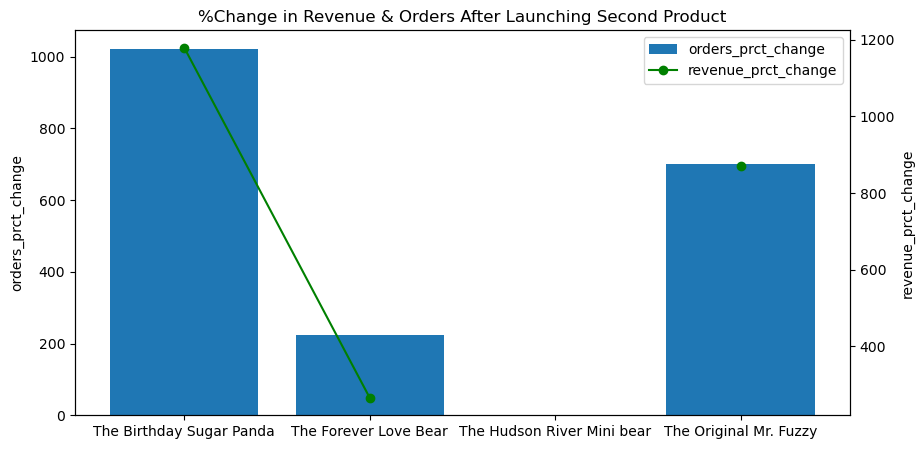

In [390]:
fig,axes = plt.subplots(figsize = (10,5))
axes.bar(prct_change_after_launch_second['product_name'],prct_change_after_launch_second['Total_orders'],label = 'orders_prct_change')
axes.set_xticks(prct_change_after_launch_second['product_name'])
axes.set_ylabel('orders_prct_change')

axes2 = axes.twinx()
axes2.plot(prct_change_after_launch_second['product_name'],prct_change_after_launch_second['Revenue'],label = 'revenue_prct_change',color = 'green',marker = 'o')
axes2.set_ylabel('revenue_prct_change')

lines,labels = axes.get_legend_handles_labels()
lines2,labels2 = axes2.get_legend_handles_labels()

axes.legend(lines+lines2,labels+labels2)

plt.title('%Change in Revenue & Orders After Launching Second Product')
plt.show()

In [391]:
### There is a positive change in revenue and orders after launching next products 
### the product the birthday sugar panda have the highest change in revenue prct_change

In [392]:
#### before official launch of product how is the orders and revenue
orders_products = orders_products.rename(columns = {'created_at_products':'launch_product_day'})
orders_products['created_at_orders'] =orders_products['created_at_orders'].dt.normalize()
orders_products['launch_product_day'] =orders_products['launch_product_day'].dt.normalize()

orders_products['Launch_Phase'] = np.where(orders_products['created_at_orders']<=orders_products['launch_product_day'],'Pre_Launch','Post_Launch')

pre_post_official_launch = orders_products.groupby(['Launch_Phase','product_name']).agg(Total_orders = ('order_id','count'),Total_Revenue = ('price_usd','sum')).reset_index()

In [393]:
### how much time it takes to get the user_login and get converted 
orders_web = website_orders[website_orders['order_id'].notna()]
time_change = (orders_web['created_at_orders']-orders_web['created_at_website']).dt.total_seconds()/3600

# Time Taken By User To Get Converted

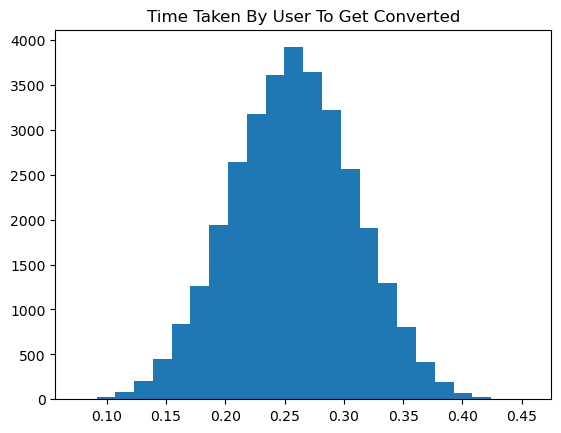

In [394]:
plt.hist(time_change,bins = 24)
plt.title('Time Taken By User To Get Converted')
plt.show()

In [395]:
time_change.to_csv('time_taken_converted.csv')

In [396]:
#### mostly customer get converted with in 15 minutes 

In [397]:
#### cohort_analysis 
cohort = orders.copy()
cohort['first_purchase'] = orders.groupby('user_id')['created_at'].transform('min')
cohort['cohort_month'] = cohort['first_purchase'].dt.to_period('M')
cohort['order_month'] = cohort['created_at'].dt.to_period('M')

cohort['cohort_index'] = (cohort['order_month'] - cohort['cohort_month']).apply(lambda x:x.n)

# Cohort Analysis Heatmap

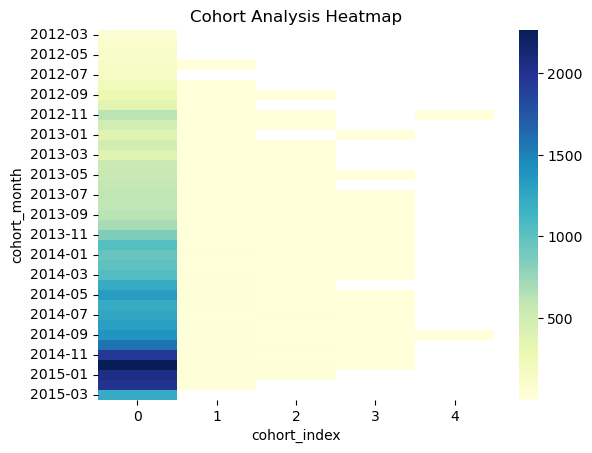

In [398]:
cohort_analysis = cohort.groupby(['cohort_month','cohort_index'])['user_id'].nunique().unstack(1)
sns.heatmap(cohort_analysis,cmap="YlGnBu")
plt.title('Cohort Analysis Heatmap')
plt.show()

In [399]:
### customer only retaining for max 4 months